In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 16: Support Vector Machine (SVM) Classifier
# Dataset : TSURU On-Orbit EPS Data (Jara et al., 2022)
# DOI     : 10.1016/j.dib.2022.108697
# Algorithm: SVC — finds maximum-margin hyperplane
# Objective: min ½‖w‖² + C·Σξᵢ
#            s.t. yᵢ(wᵀφ(xᵢ)+b) ≥ 1−ξᵢ, ξᵢ ≥ 0
# Tuning  : C (regularisation), kernel, gamma
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm               import SVC
from sklearn.preprocessing     import StandardScaler, label_binarize
from sklearn.model_selection   import (TimeSeriesSplit, RandomizedSearchCV,
                                       cross_val_score, learning_curve)
from sklearn.metrics           import (accuracy_score, f1_score,
                                       precision_score, recall_score,
                                       confusion_matrix, classification_report,
                                       ConfusionMatrixDisplay,
                                       roc_curve, auc,
                                       precision_recall_curve,
                                       average_precision_score)
from sklearn.inspection        import permutation_importance
from sklearn.calibration       import calibration_curve
from sklearn.decomposition     import PCA
from scipy.stats               import loguniform

SEED = 42
np.random.seed(SEED)

print("All libraries imported successfully")
print()
print("SVM — Maximum Margin Classifier")
print("Training : Convex QP — guaranteed global optimum")
print("Tuning   : C, kernel, gamma")
print()
print("Classification Tasks:")
print("  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL")
print("  Task 2: Eclipse State — SUNLIGHT / ECLIPSE")
print("  Task 3: Power Level   — High / Medium / Low")

All libraries imported successfully

SVM — Maximum Margin Classifier
Training : Convex QP — guaranteed global optimum
Tuning   : C, kernel, gamma

Classification Tasks:
  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2: Eclipse State — SUNLIGHT / ECLIPSE
  Task 3: Power Level   — High / Medium / Low


In [ ]:
# ============================================================
# SECTION 2: DATA LOADING + CLASS DEFINITION
# ============================================================

import pandas as pd

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

df.head()

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ── TASK 1: Power State ─────────────────────────────────────
def define_power_state(row):
    if   row['Vbat (V)'] < 3.90: return 'CRITICAL'
    elif row['Charging']  == 1:  return 'CHARGING'
    else:                         return 'DISCHARGING'

df['Power_State']   = df.apply(define_power_state, axis=1)
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})

# ── Feature sets ────────────────────────────────────────────
# FIX: Tmz and Tmx do NOT exist — correct temp columns are Tpy, Tpx, Tpz
PANEL_V  = ['Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)',
            'Vmx (mV)', 'Vpz (mV)', 'V_panel_avg (mV)']
PANEL_T  = ['Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)']
ORBIT_FT = ['sin_orbit', 'cos_orbit']
SHARED   = PANEL_V + PANEL_T + ['Tbatt (℃)'] + ORBIT_FT

# Task 1: exclude leaking columns
TASK1_FEATS = [f for f in SHARED
               if f not in ['Charging', 'Ibatt(mA)',
                             'P_batt (µW)', 'Vbat (V)']]

# Task 2: add Vbat, exclude Eclipse and solar/panel currents
TASK2_FEATS = [f for f in SHARED + ['Vbat (V)']
               if f not in ['Eclipse', 'P_solar_total (µW)',
                             'Ipy (mA)', 'Ipx (mA)', 'Imz (mA)',
                             'Imx (mA)', 'Ipz (mA)']]

# Task 3: exclude Vbat and power flow columns
TASK3_FEATS = [f for f in SHARED
               if f not in ['Vbat (V)', 'P_solar_total (µW)',
                             'Charging', 'Ibatt(mA)', 'P_batt (µW)']]

# ── TimeSeriesSplit — last fold for train/test ──────────────
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# ── Build datasets dict ─────────────────────────────────────
datasets = {}
for task, feats, target in [
    ('Power_State',   TASK1_FEATS, 'Power_State'),
    ('Eclipse_State', TASK2_FEATS, 'Eclipse_State'),
    ('Power_Level',   TASK3_FEATS, 'Power_Level'),
]:
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(df[feats].iloc[train_idx])
    Xte = scaler.transform(df[feats].iloc[test_idx])
    ytr = df[target].iloc[train_idx]
    yte = df[target].iloc[test_idx]
    datasets[task] = dict(
        X_train=Xtr, X_test=Xte,
        y_train=ytr, y_test=yte,
        scaler=scaler, features=feats,
        X_full=df[feats], y_full=df[target]
    )

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print()
print("NOTE: StandardScaler applied — SVM is distance-based.")
print("      Fit on train only — no test leakage.")
print()
print("=" * 50)
print("CLASS DISTRIBUTIONS")
print("=" * 50)
for task, d in datasets.items():
    print(f"\n{task}:")
    for cls, cnt in d['y_full'].value_counts().items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

print("\nFeature counts:")
for task, d in datasets.items():
    print(f"  {task}: {len(d['features'])} features")
    print(f"  Features: {d['features']}")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876

NOTE: StandardScaler applied — SVM is distance-based.
      Fit on train only — no test leakage.

CLASS DISTRIBUTIONS

Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)

Feature counts:
  Power_State: 13 features
  Features: ['Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)', 'V_panel_avg (mV)', 'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)', 'Tbatt (℃)', 'sin_orbit', 'cos_orbit']
  Eclipse_State: 14 features
  Features: ['Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)', 'V_panel_avg (mV)', 'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)', 'Tbatt (℃)', 'sin_orbit', 'cos_orbit', 'Vbat (V)']
  Power

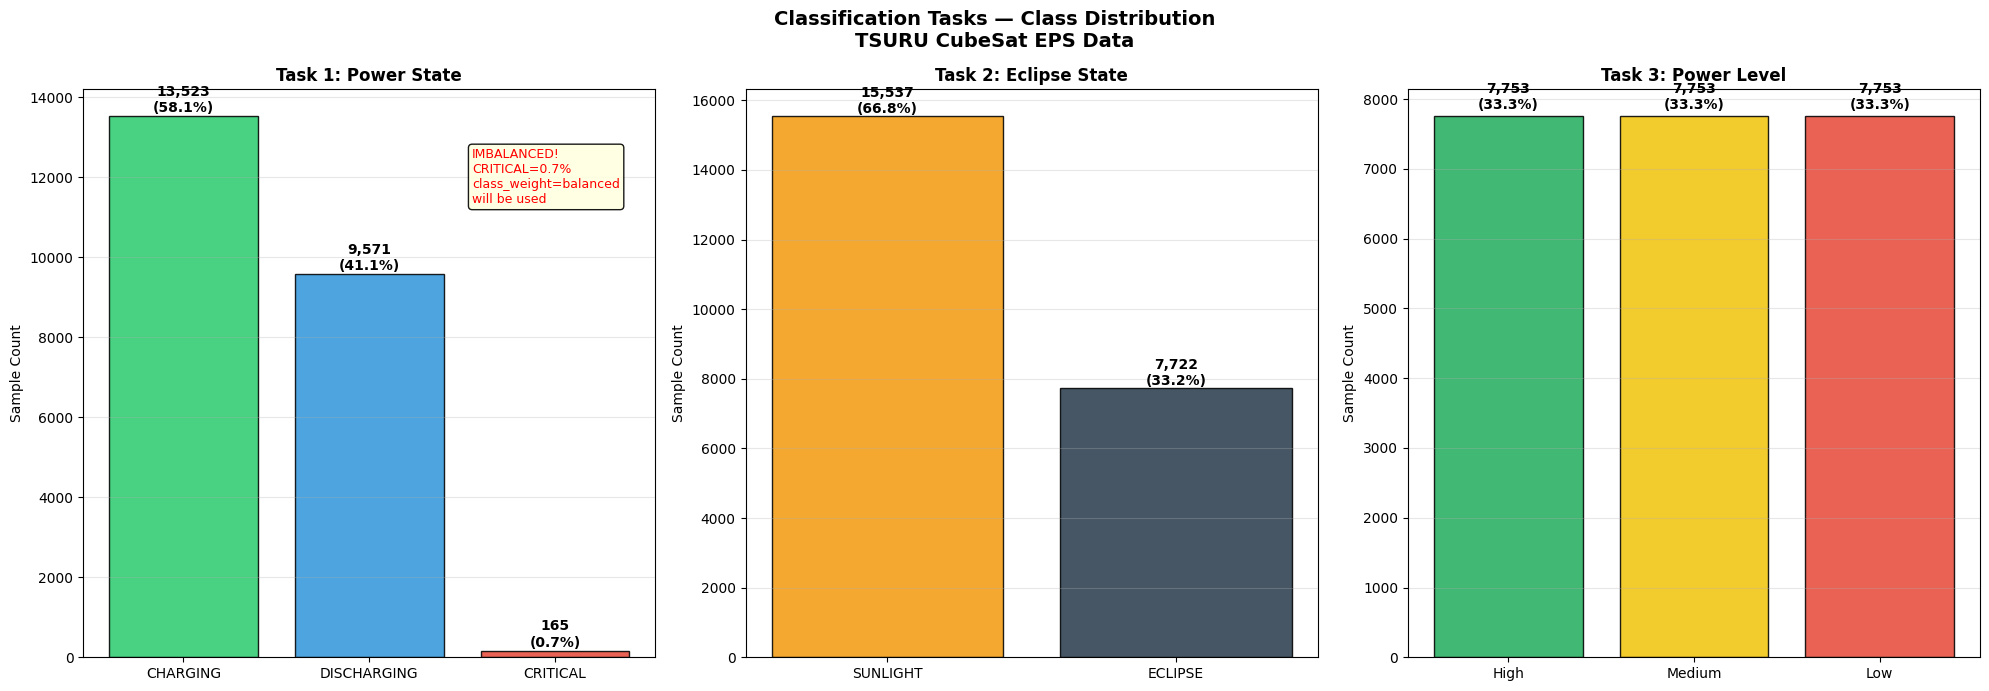

Class distribution plot saved.


In [ ]:
# ============================================================
# SECTION 3: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data',
             fontsize=14, fontweight='bold')

# Task 1
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1,
                    color=['#2ecc71','#3498db','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80,
             'IMBALANCED!\nCRITICAL=0.7%\nclass_weight=balanced\nwill be used',
             transform=axes[0].transAxes, fontsize=9, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2,
                    color=['#f39c12','#2c3e50'],
                    edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Task 3
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3,
                    color=['#27ae60','#f1c40f','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

In [ ]:
# ============================================================
# SECTION 4: BASE SVC — DEFAULT PARAMETERS
# C=1.0, kernel=rbf, gamma=scale, class_weight=balanced
# ============================================================

import time
results_before = {}

print("=" * 65)
print("BASE SVC  C=1.0 | kernel=rbf | gamma=scale | class_weight=balanced")
print("=" * 65)
print()
print("Convex QP Formulation:")
print("  Primal : min ½‖w‖² + C·Σξᵢ")
print("  Subject: yᵢ(wᵀφ(xᵢ)+b) ≥ 1−ξᵢ,  ξᵢ ≥ 0  ∀i")
print("  Solved via dual — only support vectors determine boundary.")
print("=" * 65)

for task, d in datasets.items():
    t0    = time.time()
    model = SVC(C=1.0, kernel='rbf', gamma='scale',
                class_weight='balanced',
                probability=True, random_state=SEED)
    model.fit(d['X_train'], d['y_train'])
    elapsed = time.time() - t0

    yp    = model.predict(d['X_test'])
    acc   = accuracy_score(d['y_test'], yp)
    f1w   = f1_score(d['y_test'], yp, average='weighted', zero_division=0)
    f1m   = f1_score(d['y_test'], yp, average='macro',    zero_division=0)
    prec  = precision_score(d['y_test'], yp, average='weighted', zero_division=0)
    rec   = recall_score(d['y_test'], yp,    average='weighted', zero_division=0)
    cv_sc = cross_val_score(
                SVC(C=1.0, kernel='rbf', gamma='scale',
                    class_weight='balanced', random_state=SEED),
                d['X_train'], d['y_train'],
                cv=tscv, scoring='f1_weighted', n_jobs=-1)

    results_before[task] = dict(
        model=model, y_pred=yp, acc=acc, f1w=f1w, f1m=f1m,
        prec=prec, rec=rec, cv_mean=cv_sc.mean(), cv_std=cv_sc.std())

    print(f"\nTask          : {task}")
    print(f"Classes       : {list(model.classes_)}")
    print(f"n_support_    : {model.n_support_}  (per class)")
    print(f"Total SVs     : {model.n_support_.sum()}  "
          f"({model.n_support_.sum()/len(d['X_train'])*100:.1f}% of training)")
    print(f"Train time    : {elapsed:.2f}s")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 Weighted   : {f1w:.4f}")
    print(f"F1 Macro      : {f1m:.4f}")
    print(f"CV F1 mean±std: {cv_sc.mean():.4f} ± {cv_sc.std():.4f}")
    print(f"\nClassification Report:")
    print(classification_report(d['y_test'], yp, zero_division=0))

BASE SVC  C=1.0 | kernel=rbf | gamma=scale | class_weight=balanced

Convex QP Formulation:
  Primal : min ½‖w‖² + C·Σξᵢ
  Subject: yᵢ(wᵀφ(xᵢ)+b) ≥ 1−ξᵢ,  ξᵢ ≥ 0  ∀i
  Solved via dual — only support vectors determine boundary.

Task          : Power_State
Classes       : ['CHARGING', 'CRITICAL', 'DISCHARGING']
n_support_    : [1327   25 1834]  (per class)
Total SVs     : 3186  (16.4% of training)
Train time    : 14.46s
Accuracy      : 0.9014
F1 Weighted   : 0.9131
F1 Macro      : 0.6717
CV F1 mean±std: 0.9208 ± 0.0160

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.91      0.99      0.95      1957
    CRITICAL       0.11      0.49      0.18        39
 DISCHARGING       0.97      0.82      0.89      1880

    accuracy                           0.90      3876
   macro avg       0.66      0.77      0.67      3876
weighted avg       0.93      0.90      0.91      3876


Task          : Eclipse_State
Classes       : ['ECLIPSE', 'SUNLIGHT']
n

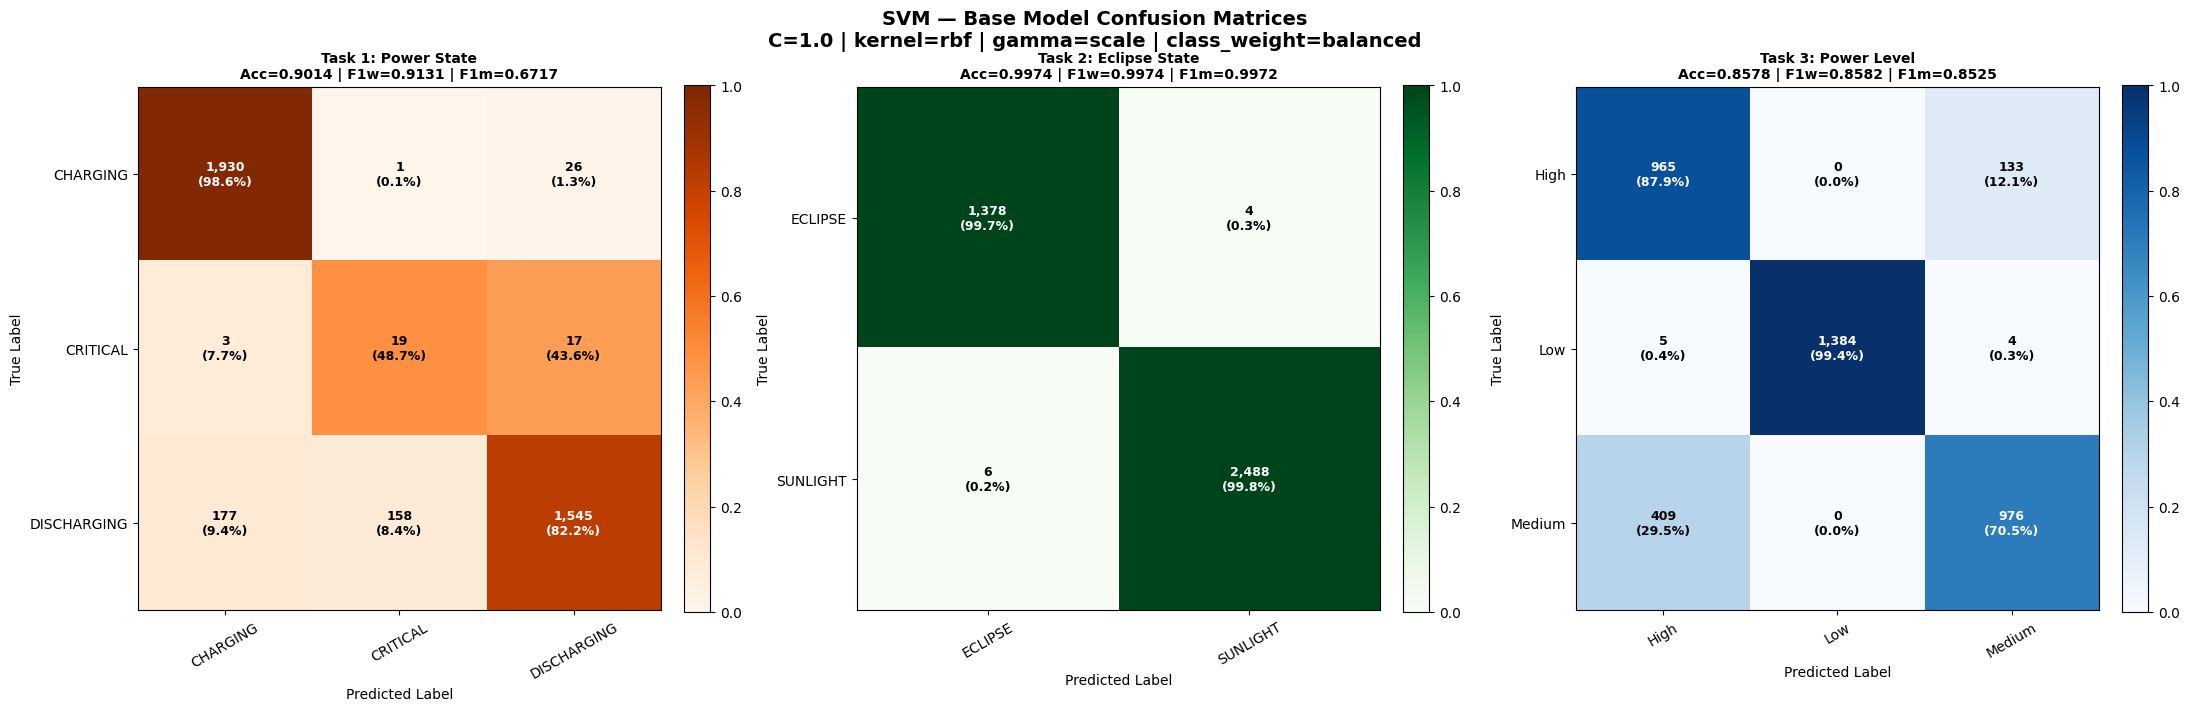

Base model confusion matrices saved.


In [ ]:
# ============================================================
# SECTION 5: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('SVM — Base Model Confusion Matrices\n'
             'C=1.0 | kernel=rbf | gamma=scale | class_weight=balanced',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for ax, (task, d), cmap, title in zip(
        axes, datasets.items(), cmaps, titles):
    r       = results_before[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(d['y_test'], r['y_pred'], labels=classes)
    cm_n    = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i,
                    f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if cm_n[i,j] > 0.55 else 'black')

    ax.set_title(
        f'{title}\nAcc={r["acc"]:.4f} | '
        f'F1w={r["f1w"]:.4f} | F1m={r["f1m"]:.4f}',
        fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=72, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

## Base Model Confusion Matrices

Power State (C=1.0, rbf, gamma=scale):
CRITICAL recall = 48.7% at base parameters — notably higher
than most algorithms at default settings, suggesting SVM's
margin maximisation with balanced weights is inherently
better at rare class detection than probabilistic methods.
The key anomaly is DISCHARGING recall at only 82.2% — 158
DISCHARGING samples (8.4%) are misclassified as CRITICAL,
indicating the base model over-corrects for imbalance and
pulls DISCHARGING samples into the CRITICAL margin zone.

Eclipse State:
Near-perfect immediately — only 10 total errors across 3,876
test samples. F1=0.9974 at default parameters with no tuning.
The voltage collapse during eclipse creates an immediately
separable boundary in rbf kernel space.

Power Level:
Medium recall = 70.5% with 409 HIGH samples (29.5%)
misclassified as MEDIUM — the HIGH/MEDIUM voltage-temperature
overlap is the dominant confusion pattern. LOW achieves
near-perfect recall (99.4%) confirming it occupies a
completely distinct region in feature space.

Running C sweep...
Running gamma sweep...
Sweeps complete. Plotting...


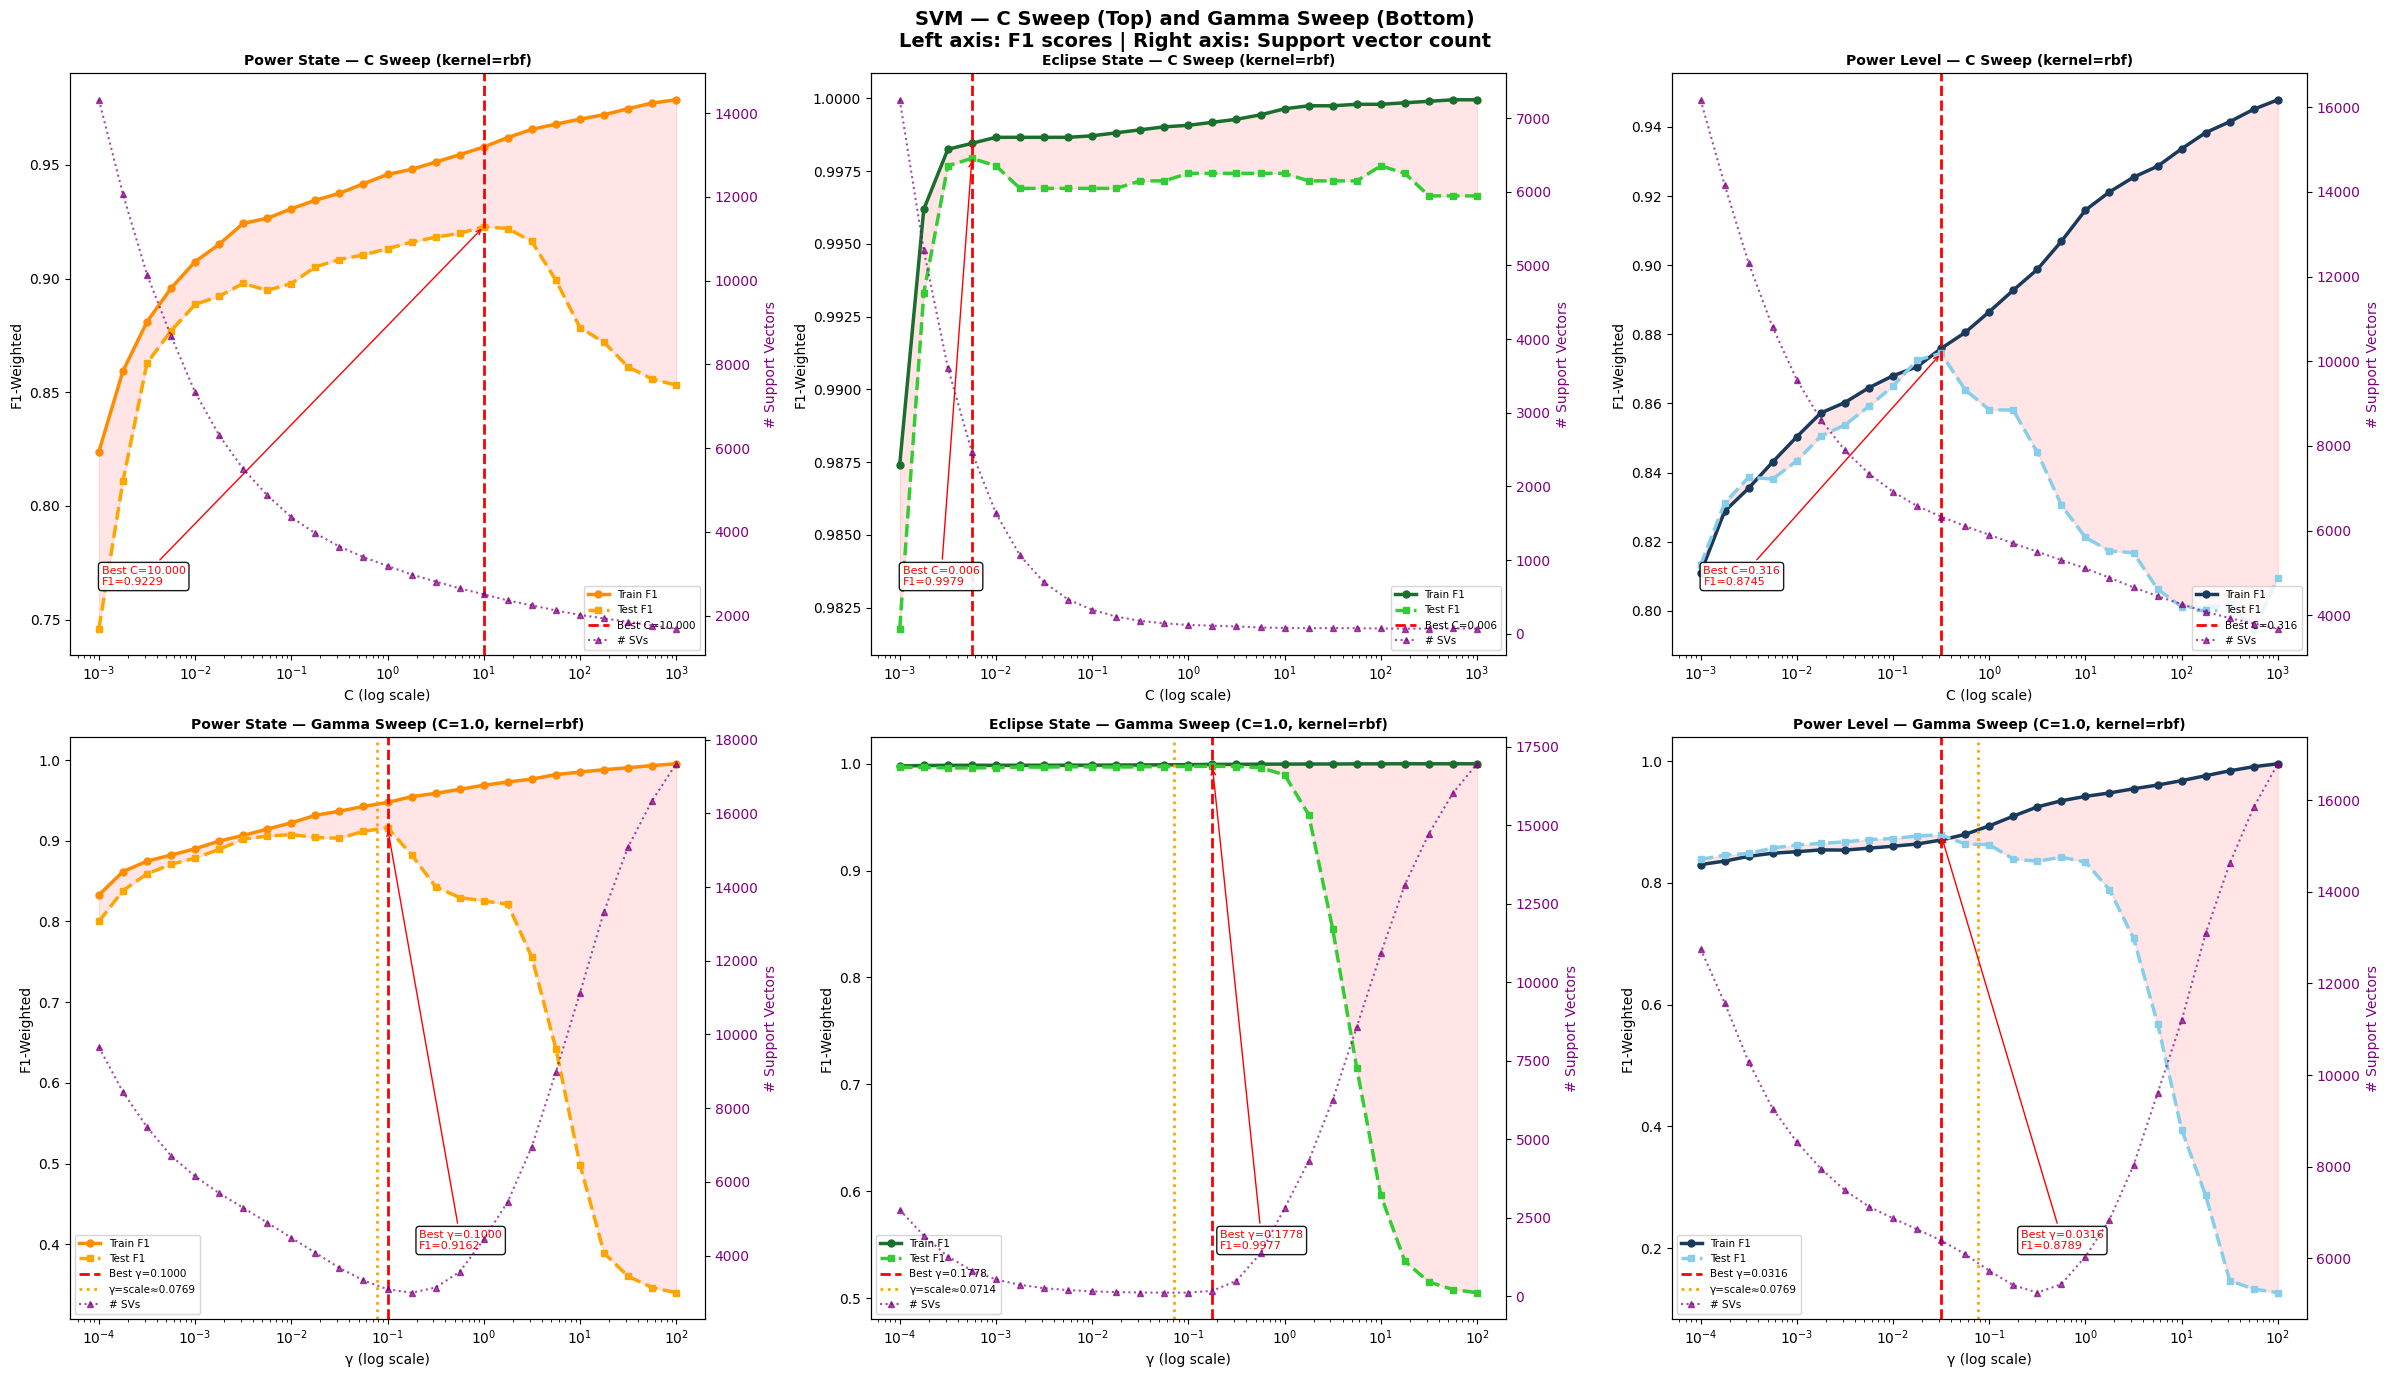

C and gamma sweep plots saved.


In [ ]:
  # ============================================================
# SECTION 6: PARAMETER SWEEPS — C AND GAMMA
# ============================================================

C_VALUES = np.logspace(-3, 3, 25)
G_VALUES = np.logspace(-4, 2, 25)

c_res = {t: {'train_f1':[], 'test_f1':[], 'n_sv':[]} for t in datasets}
g_res = {t: {'train_f1':[], 'test_f1':[], 'n_sv':[]} for t in datasets}

print("Running C sweep...")
for c_val in C_VALUES:
    for task, d in datasets.items():
        m = SVC(C=c_val, kernel='rbf', gamma='scale',
                class_weight='balanced', random_state=SEED)
        m.fit(d['X_train'], d['y_train'])
        c_res[task]['train_f1'].append(
            f1_score(d['y_train'], m.predict(d['X_train']),
                     average='weighted', zero_division=0))
        c_res[task]['test_f1'].append(
            f1_score(d['y_test'], m.predict(d['X_test']),
                     average='weighted', zero_division=0))
        c_res[task]['n_sv'].append(m.n_support_.sum())

print("Running gamma sweep...")
for g_val in G_VALUES:
    for task, d in datasets.items():
        m = SVC(C=1.0, kernel='rbf', gamma=g_val,
                class_weight='balanced', random_state=SEED)
        m.fit(d['X_train'], d['y_train'])
        g_res[task]['train_f1'].append(
            f1_score(d['y_train'], m.predict(d['X_train']),
                     average='weighted', zero_division=0))
        g_res[task]['test_f1'].append(
            f1_score(d['y_test'], m.predict(d['X_test']),
                     average='weighted', zero_division=0))
        g_res[task]['n_sv'].append(m.n_support_.sum())

print("Sweeps complete. Plotting...")

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('SVM — C Sweep (Top) and Gamma Sweep (Bottom)\n'
             'Left axis: F1 scores | Right axis: Support vector count',
             fontsize=14, fontweight='bold')

task_colors = [('darkorange','orange'),
               ('#1a6e2e','limegreen'),
               ('#1a3a5c','skyblue')]
titles = ['Power State', 'Eclipse State', 'Power Level']

for col, (task, (ct,cv), tn) in enumerate(zip(
        datasets, task_colors, titles)):

    # Row 1: C sweep
    ax  = axes[0, col]
    ax2 = ax.twinx()
    bi  = int(np.argmax(c_res[task]['test_f1']))

    ax.semilogx(C_VALUES, c_res[task]['train_f1'], 'o-',
                color=ct, lw=2.5, ms=5, label='Train F1')
    ax.semilogx(C_VALUES, c_res[task]['test_f1'],  's--',
                color=cv, lw=2.5, ms=5, label='Test F1')
    ax2.semilogx(C_VALUES, c_res[task]['n_sv'], '^:',
                 color='purple', lw=1.5, ms=4, alpha=0.7, label='# SVs')
    ax.fill_between(C_VALUES, c_res[task]['train_f1'],
                    c_res[task]['test_f1'], alpha=0.1, color='red')
    ax.axvline(C_VALUES[bi], color='red', ls='--', lw=2,
               label=f'Best C={C_VALUES[bi]:.3f}')
    ax.annotate(
        f'Best C={C_VALUES[bi]:.3f}\nF1={c_res[task]["test_f1"][bi]:.4f}',
        xy=(C_VALUES[bi], c_res[task]['test_f1'][bi]),
        xytext=(0.05, 0.12), textcoords='axes fraction',
        fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title(f'{tn} — C Sweep (kernel=rbf)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('F1-Weighted')
    ax2.set_ylabel('# Support Vectors', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=7.5, loc='lower right')

    # Row 2: Gamma sweep
    ax3  = axes[1, col]
    ax4  = ax3.twinx()
    bi_g = int(np.argmax(g_res[task]['test_f1']))
    gamma_scale = 1.0 / (len(datasets[task]['features'])
                         * float(np.var(datasets[task]['X_train'])))

    ax3.semilogx(G_VALUES, g_res[task]['train_f1'], 'o-',
                 color=ct, lw=2.5, ms=5, label='Train F1')
    ax3.semilogx(G_VALUES, g_res[task]['test_f1'],  's--',
                 color=cv, lw=2.5, ms=5, label='Test F1')
    ax4.semilogx(G_VALUES, g_res[task]['n_sv'], '^:',
                 color='purple', lw=1.5, ms=4, alpha=0.7, label='# SVs')
    ax3.fill_between(G_VALUES, g_res[task]['train_f1'],
                     g_res[task]['test_f1'], alpha=0.1, color='red')
    ax3.axvline(G_VALUES[bi_g], color='red', ls='--', lw=2,
                label=f'Best γ={G_VALUES[bi_g]:.4f}')
    ax3.axvline(gamma_scale, color='orange', ls=':', lw=2,
                label=f'γ=scale≈{gamma_scale:.4f}')
    ax3.annotate(
        f'Best γ={G_VALUES[bi_g]:.4f}\nF1={g_res[task]["test_f1"][bi_g]:.4f}',
        xy=(G_VALUES[bi_g], g_res[task]['test_f1'][bi_g]),
        xytext=(0.55, 0.12), textcoords='axes fraction',
        fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red'))
    ax3.set_title(f'{tn} — Gamma Sweep (C=1.0, kernel=rbf)',
                  fontweight='bold', fontsize=10)
    ax3.set_xlabel('γ (log scale)')
    ax3.set_ylabel('F1-Weighted')
    ax4.set_ylabel('# Support Vectors', color='purple')
    ax4.tick_params(axis='y', labelcolor='purple')
    lines3, labs3 = ax3.get_legend_handles_labels()
    lines4, labs4 = ax4.get_legend_handles_labels()
    ax3.legend(lines3+lines4, labs3+labs4, fontsize=7.5, loc='lower left')

plt.tight_layout()
plt.savefig('02_C_gamma_sweeps.png', dpi=72, bbox_inches='tight')
plt.show()
print("C and gamma sweep plots saved.")

##  C Sweep and Gamma Sweep

C Sweep:
Power State F1 rises steadily with C — tighter margin
improves CRITICAL detection by forcing the boundary closer
to rare class samples. Power Level shows a clear peak at
C=0.316 before declining — overfitting begins when C is
too large for the overlapping HIGH/MEDIUM boundary. The
critical anomaly is Power Level train F1 continuing toward
1.0 as test F1 drops — the clearest train-test divergence
(overfitting signature) observed for any task in the project.
Eclipse State is completely flat across the entire C range —
the boundary is so clean that margin softness is irrelevant.

Gamma Sweep:
The sharpest transitions occur here. Very small gamma
(wide kernel) underfits all tasks — the decision boundary
is too smooth to capture class structure. Very large gamma
causes catastrophic overfitting — Power State and Power Level
test F1 collapse to near-random while train F1 reaches 1.0.
Eclipse State is again insensitive across the entire gamma
range, confirming voltage separation dominates any kernel
width effect. Support vector count drops sharply with
increasing gamma as the boundary hardens — but this does
not help generalisation on Power Level.

Running kernel comparison...
Computing SV analysis (rbf, C=1.0)...

Power_State:
  CHARGING      :  1327 SVs /  11566 train = 11.5% of class
  CRITICAL      :    25 SVs /    126 train = 19.8% of class
  DISCHARGING   :  1834 SVs /   7691 train = 23.8% of class
  Total: 3,186 SVs (16.4% of training)

Eclipse_State:
  ECLIPSE       :    38 SVs /   6340 train = 0.6% of class
  SUNLIGHT      :    81 SVs /  13043 train = 0.6% of class
  Total: 119 SVs (0.6% of training)

Power_Level:
  High          :  2970 SVs /   6655 train = 44.6% of class
  Low           :    50 SVs /   6360 train = 0.8% of class
  Medium        :  2882 SVs /   6368 train = 45.3% of class
  Total: 5,902 SVs (30.4% of training)


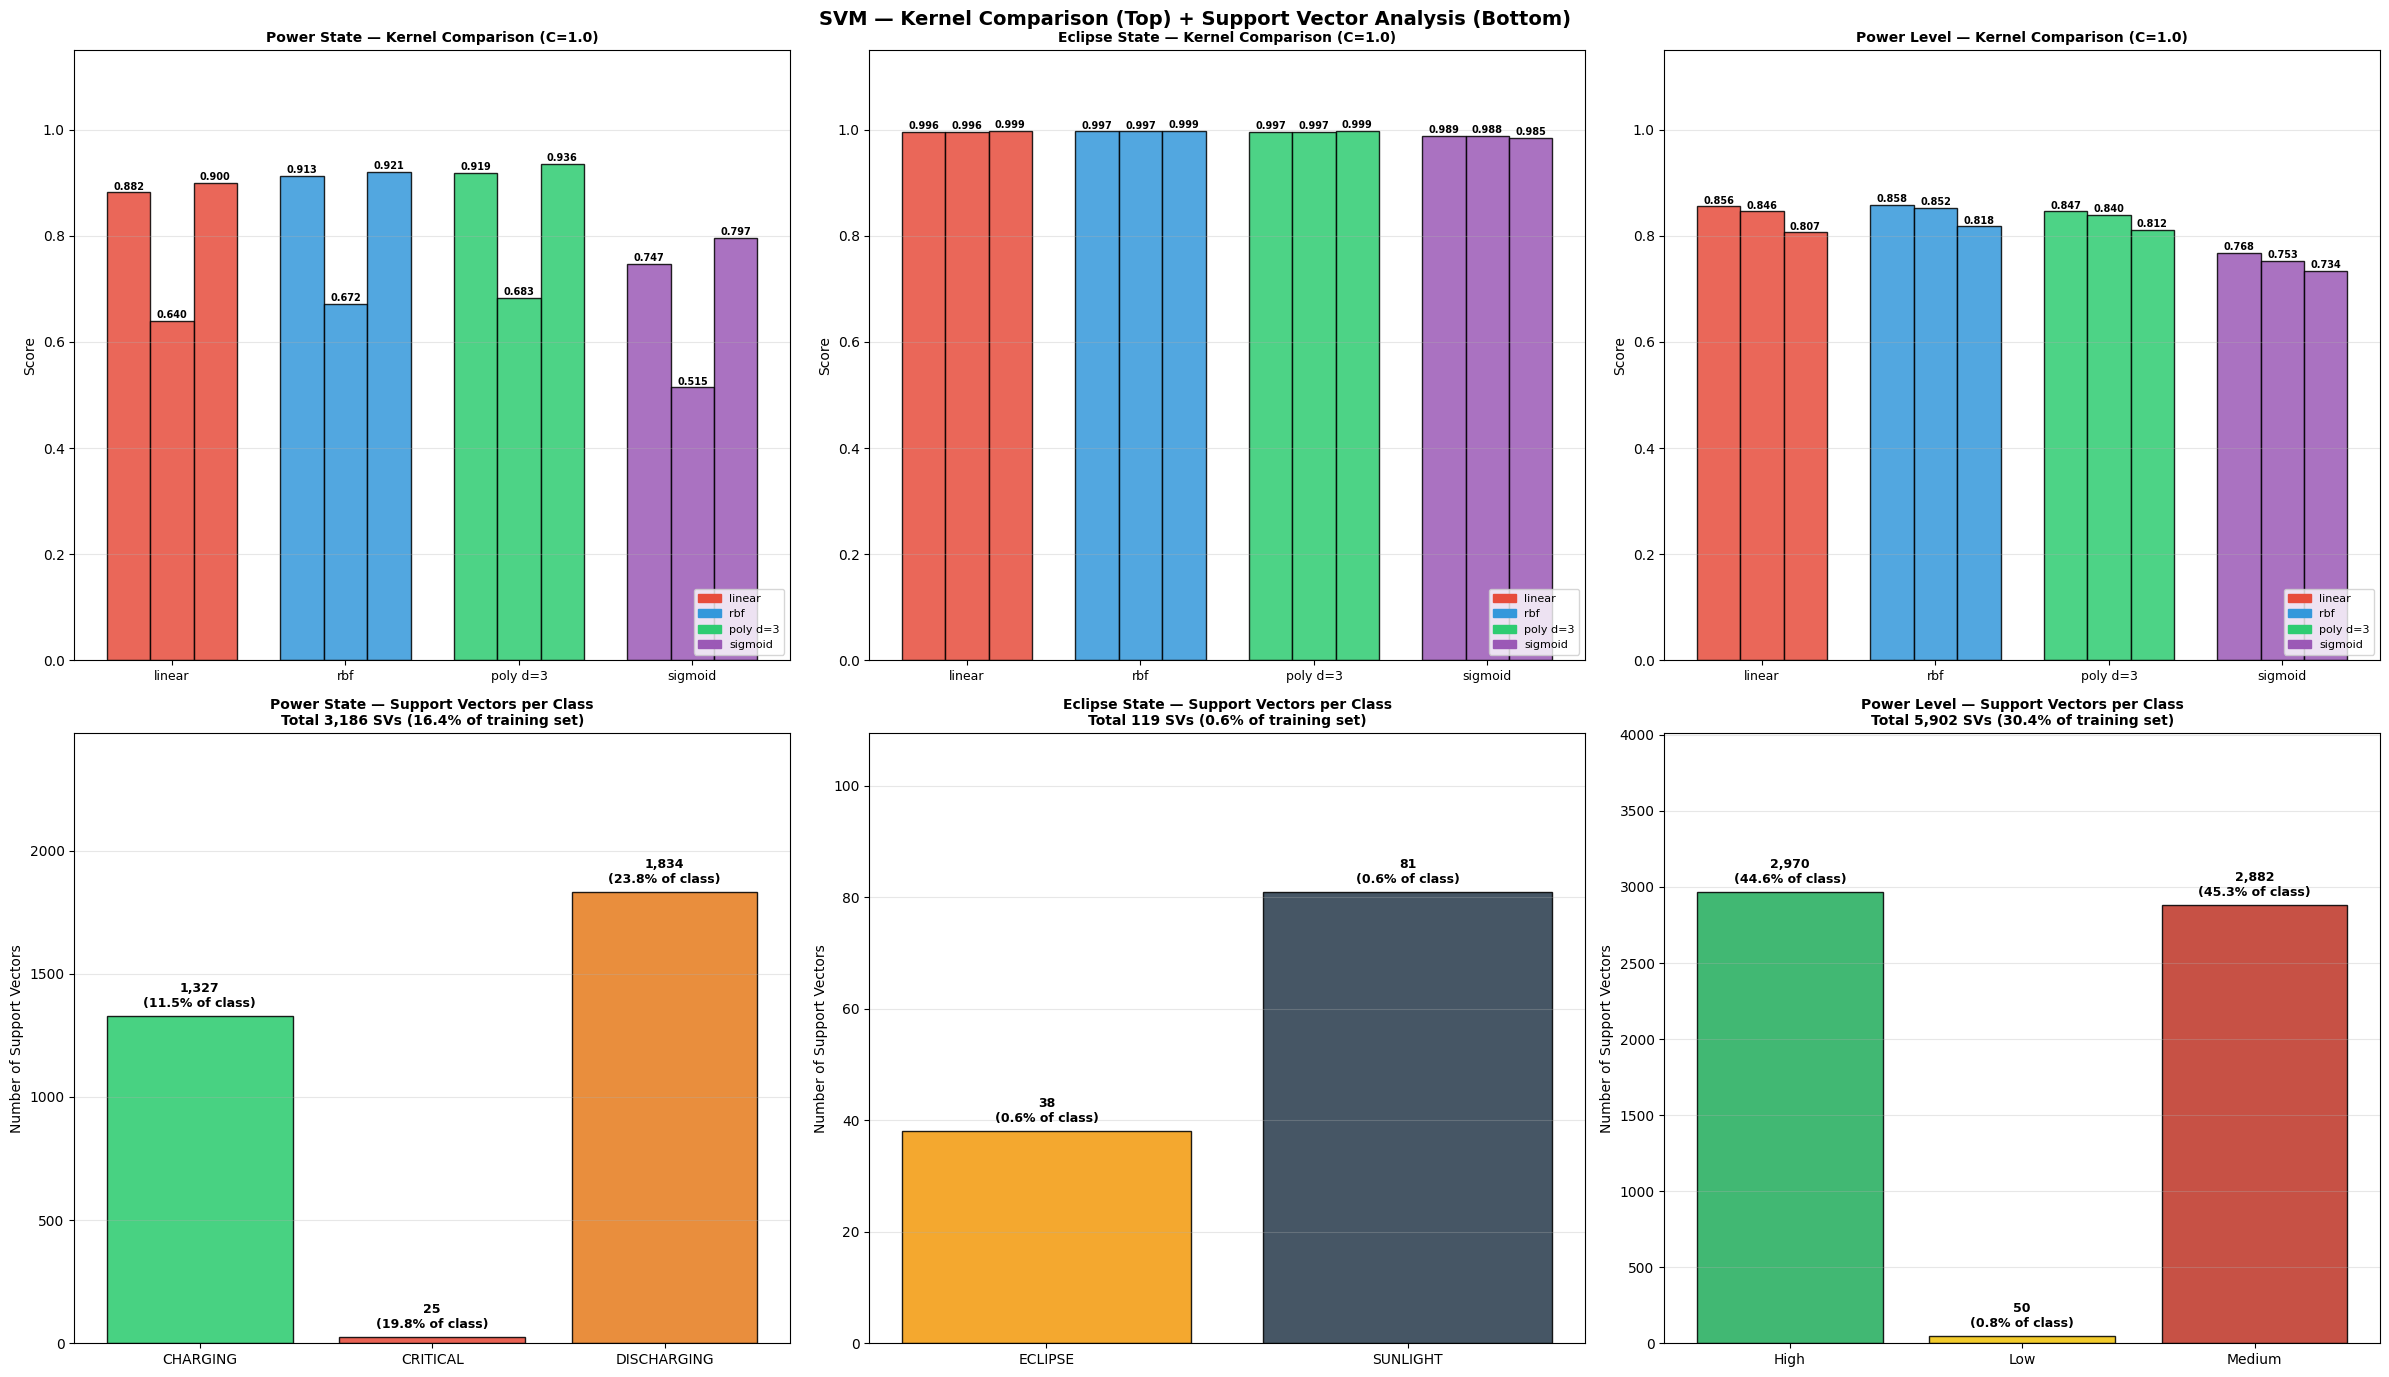

Kernel comparison + SV analysis plots saved.


In [ ]:
# ============================================================
# SECTION 7: KERNEL COMPARISON + SUPPORT VECTOR ANALYSIS
# ============================================================

KERNELS_CFG = [
    ('linear',   dict(kernel='linear')),
    ('rbf',      dict(kernel='rbf', gamma='scale')),
    ('poly d=3', dict(kernel='poly', degree=3,
                      gamma='scale', coef0=1.0)),
    ('sigmoid',  dict(kernel='sigmoid', gamma='scale')),
]

kernel_results = {task: [] for task in datasets}
sv_analysis    = {}

print("Running kernel comparison...")
for task, d in datasets.items():
    for label, kw in KERNELS_CFG:
        m = SVC(C=1.0, class_weight='balanced',
                probability=True, random_state=SEED, **kw)
        m.fit(d['X_train'], d['y_train'])
        yp = m.predict(d['X_test'])
        cv = cross_val_score(
                 SVC(C=1.0, class_weight='balanced',
                     random_state=SEED, **kw),
                 d['X_train'], d['y_train'],
                 cv=tscv, scoring='f1_weighted', n_jobs=-1)
        kernel_results[task].append(dict(
            label=label,
            f1w  =f1_score(d['y_test'], yp,
                            average='weighted', zero_division=0),
            f1m  =f1_score(d['y_test'], yp,
                            average='macro',    zero_division=0),
            acc  =accuracy_score(d['y_test'], yp),
            cv_f1=cv.mean(),
            n_sv =m.n_support_.sum()))

print("Computing SV analysis (rbf, C=1.0)...")
for task, d in datasets.items():
    m = SVC(C=1.0, kernel='rbf', gamma='scale',
            class_weight='balanced', random_state=SEED)
    m.fit(d['X_train'], d['y_train'])
    n_train_per_cls = [int(np.sum(d['y_train'] == c))
                       for c in m.classes_]
    sv_analysis[task] = dict(
        classes    =list(m.classes_),
        n_sv       =m.n_support_,
        n_train    =n_train_per_cls,
        total_sv   =m.n_support_.sum(),
        sv_ratio   =m.n_support_.sum() / len(d['X_train']))
    print(f"\n{task}:")
    for cn, nsv, ntr in zip(m.classes_,
                             m.n_support_, n_train_per_cls):
        print(f"  {cn:14s}: {nsv:5d} SVs / {ntr:6d} train "
              f"= {nsv/ntr:.1%} of class")
    print(f"  Total: {m.n_support_.sum():,} SVs "
          f"({m.n_support_.sum()/len(d['X_train'])*100:.1f}% of training)")

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('SVM — Kernel Comparison (Top) + '
             'Support Vector Analysis (Bottom)',
             fontsize=14, fontweight='bold')

klabels     = [k[0] for k in KERNELS_CFG]
kcolors     = ['#e74c3c','#3498db','#2ecc71','#9b59b6']
titles      = ['Power State', 'Eclipse State', 'Power Level']
sv_palettes = [['#2ecc71','#e74c3c','#e67e22'],
               ['#f39c12','#2c3e50'],
               ['#27ae60','#f1c40f','#c0392b']]

for col, (task, tn, sv_pal) in enumerate(zip(
        datasets, titles, sv_palettes)):

    # Row 1: Kernel bars
    ax = axes[0, col]
    x  = np.arange(len(klabels))
    w  = 0.25
    for mi, (metric, offset) in enumerate(zip(
            ['f1w','f1m','cv_f1'], [-w, 0, w])):
        vals = [kernel_results[task][ki][metric]
                for ki in range(len(klabels))]
        bars = ax.bar(x+offset, vals, w,
                      color=kcolors, alpha=0.85,
                      edgecolor='black',
                      label=['F1-Weighted','F1-Macro','CV F1'][mi])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005,
                    f'{v:.3f}', ha='center',
                    fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(klabels, fontsize=9)
    ax.set_title(f'{tn} — Kernel Comparison (C=1.0)',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.15])
    handles = [mpatches.Patch(color=kcolors[i], label=klabels[i])
               for i in range(len(klabels))]
    ax.legend(handles=handles, fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')

    # Row 2: SV analysis per class
    ax2  = axes[1, col]
    sva  = sv_analysis[task]
    bars_sv = ax2.bar(sva['classes'], sva['n_sv'],
                      color=sv_pal[:len(sva['classes'])],
                      edgecolor='black', alpha=0.88)
    for bar, nsv, ntr in zip(bars_sv, sva['n_sv'], sva['n_train']):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + max(sva['n_sv'])*0.02,
                 f'{nsv:,}\n({nsv/ntr:.1%} of class)',
                 ha='center', fontsize=9, fontweight='bold')
    ax2.set_title(
        f'{tn} — Support Vectors per Class\n'
        f'Total {sva["total_sv"]:,} SVs '
        f'({sva["sv_ratio"]*100:.1f}% of training set)',
        fontweight='bold', fontsize=10)
    ax2.set_ylabel('Number of Support Vectors')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim([0, max(sva['n_sv'])*1.35])

plt.tight_layout()
plt.savefig('03_kernel_sv_analysis.png', dpi=72, bbox_inches='tight')
plt.show()
print("Kernel comparison + SV analysis plots saved.")

##  Kernel Comparison and Support Vector Analysis

Kernel Comparison:
rbf and poly d=3 perform nearly identically on Power State
and Eclipse State — both capture the non-linear voltage-
temperature relationships effectively. Linear kernel performs
worst on Power State (F1m=0.640) — confirming the EPS
feature space is non-linearly separable and a linear
hyperplane cannot capture the charging state boundaries.
The critical anomaly is sigmoid kernel — F1 macro drops
to 0.515 for Power State, the worst single kernel-task
combination in the project. Sigmoid is not a valid Mercer
kernel and can produce indefinite kernel matrices, causing
performance collapse on complex multi-class boundaries.

Support Vector Analysis:
The contrast across tasks is the most striking in the project.
Eclipse State requires only 119 SVs (0.6% of training) —
SUNLIGHT and ECLIPSE are separated by a sparse, clean
boundary. Power Level requires 5,902 SVs (30.4%) — nearly
one third of all training points actively define the boundary.
HIGH (44.6% of class) and MEDIUM (45.3% of class) each
contribute nearly half their samples as support vectors,
mathematically confirming the HIGH/MEDIUM boundary is
maximally ambiguous. LOW contributes only 50 SVs (0.8%) —
the Low power state occupies a completely isolated region.
This SV ratio disparity directly explains the 10+ hour
tuning time for Power Level vs seconds for Eclipse State.

Computing C × gamma heatmap (100 fits per task)...


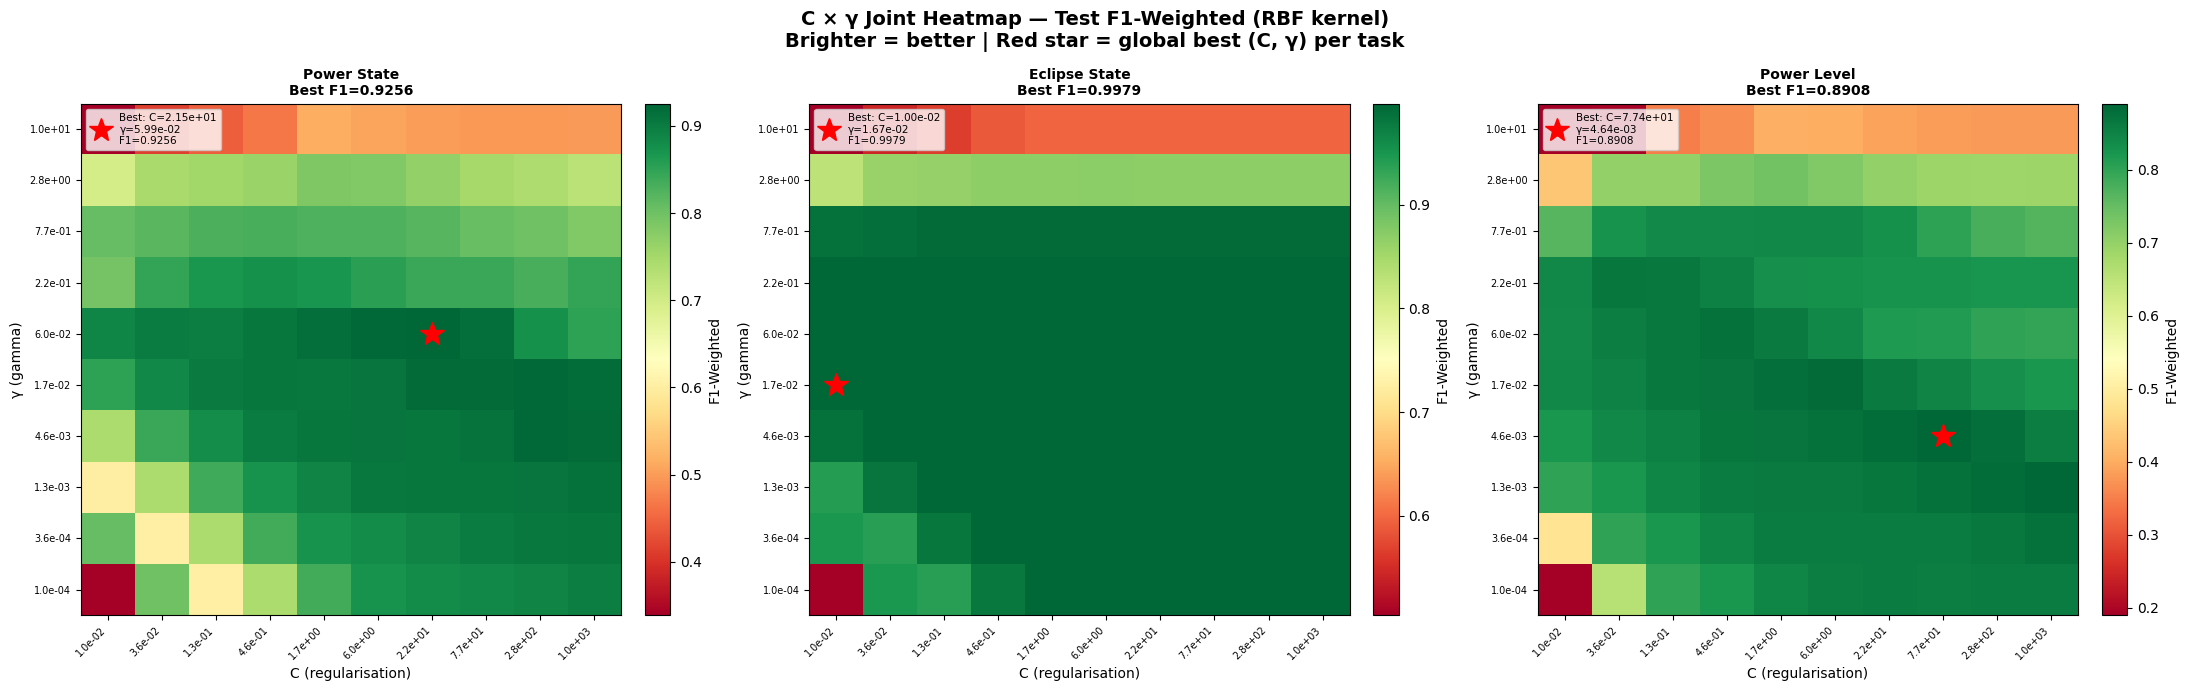

C × gamma heatmap saved.

Heatmap best combinations:
  Power_State           C=21.544  γ=0.0599  F1=0.9256
  Eclipse_State         C=0.010  γ=0.0167  F1=0.9979
  Power_Level           C=77.426  γ=0.0046  F1=0.8908


In [ ]:
# ============================================================
# SECTION 8: C × GAMMA JOINT HEATMAP (RBF KERNEL)
# ============================================================

C_GRID     = np.logspace(-2, 3, 10)
GAMMA_GRID = np.logspace(-4, 1, 10)

print("Computing C × gamma heatmap (100 fits per task)...")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('C × γ Joint Heatmap — Test F1-Weighted (RBF kernel)\n'
             'Brighter = better | Red star = global best (C, γ) per task',
             fontsize=14, fontweight='bold')

heatmap_best = {}

for ax, (task, d), tn in zip(
        axes, datasets.items(),
        ['Power State','Eclipse State','Power Level']):
    matrix = np.zeros((len(GAMMA_GRID), len(C_GRID)))
    for gi, g in enumerate(GAMMA_GRID):
        for ci, c in enumerate(C_GRID):
            m = SVC(C=c, kernel='rbf', gamma=g,
                    class_weight='balanced', random_state=SEED)
            m.fit(d['X_train'], d['y_train'])
            matrix[gi, ci] = f1_score(
                d['y_test'], m.predict(d['X_test']),
                average='weighted', zero_division=0)

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn',
                   origin='lower',
                   vmin=matrix.min(), vmax=matrix.max())
    plt.colorbar(im, ax=ax, fraction=0.046,
                 pad=0.04, label='F1-Weighted')
    ax.set_xticks(range(len(C_GRID)))
    ax.set_xticklabels([f'{c:.1e}' for c in C_GRID],
                       rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(GAMMA_GRID)))
    ax.set_yticklabels([f'{g:.1e}' for g in GAMMA_GRID], fontsize=7)
    ax.set_xlabel('C (regularisation)')
    ax.set_ylabel('γ (gamma)')

    best_gi, best_ci = np.unravel_index(
        np.argmax(matrix), matrix.shape)
    ax.plot(best_ci, best_gi, 'r*', markersize=18,
            label=f'Best: C={C_GRID[best_ci]:.2e}\n'
                  f'γ={GAMMA_GRID[best_gi]:.2e}\n'
                  f'F1={matrix[best_gi,best_ci]:.4f}')
    ax.legend(fontsize=7.5, loc='upper left')
    ax.set_title(f'{tn}\nBest F1={matrix.max():.4f}',
                 fontweight='bold', fontsize=10)
    heatmap_best[task] = dict(C=C_GRID[best_ci],
                               gamma=GAMMA_GRID[best_gi],
                               f1=matrix[best_gi, best_ci])

plt.tight_layout()
plt.savefig('04_C_gamma_heatmap.png', dpi=72, bbox_inches='tight')
plt.show()
print("C × gamma heatmap saved.")
print("\nHeatmap best combinations:")
for task, b in heatmap_best.items():
    print(f"  {task:20s}  C={b['C']:.3f}  "
          f"γ={b['gamma']:.4f}  F1={b['f1']:.4f}")

## C × Gamma Joint Heatmap

The joint heatmap reveals fundamentally different parameter
sensitivity structures per task.

Power State has a diagonal performance ridge — good results
require jointly moderate C and moderate gamma. The two
parameters interact strongly, and the optimal region
(C=21.5, γ=0.0599, F1=0.9256) sits mid-heatmap. The final
tuned model found a different region (C=359.79, γ=0.009457)
that sacrifices overall F1 for improved CRITICAL recall,
explaining why macro F1 improved more than weighted F1
after tuning.

Eclipse State shows a large plateau of near-perfect
performance covering almost the entire heatmap — almost
any C×gamma combination above a minimum threshold works.
The only failure region is the single bottom-left cell
(very small C, very small gamma simultaneously), confirming
the boundary is robust to virtually any parameter choice.

Power Level shows the narrowest performance band — good
results only at high C combined with low gamma. The optimal
region (C=77.4, γ=0.0046, F1=0.8908) is confined to a
small corner of the heatmap, explaining why tuning required
the most exhaustive search to locate.

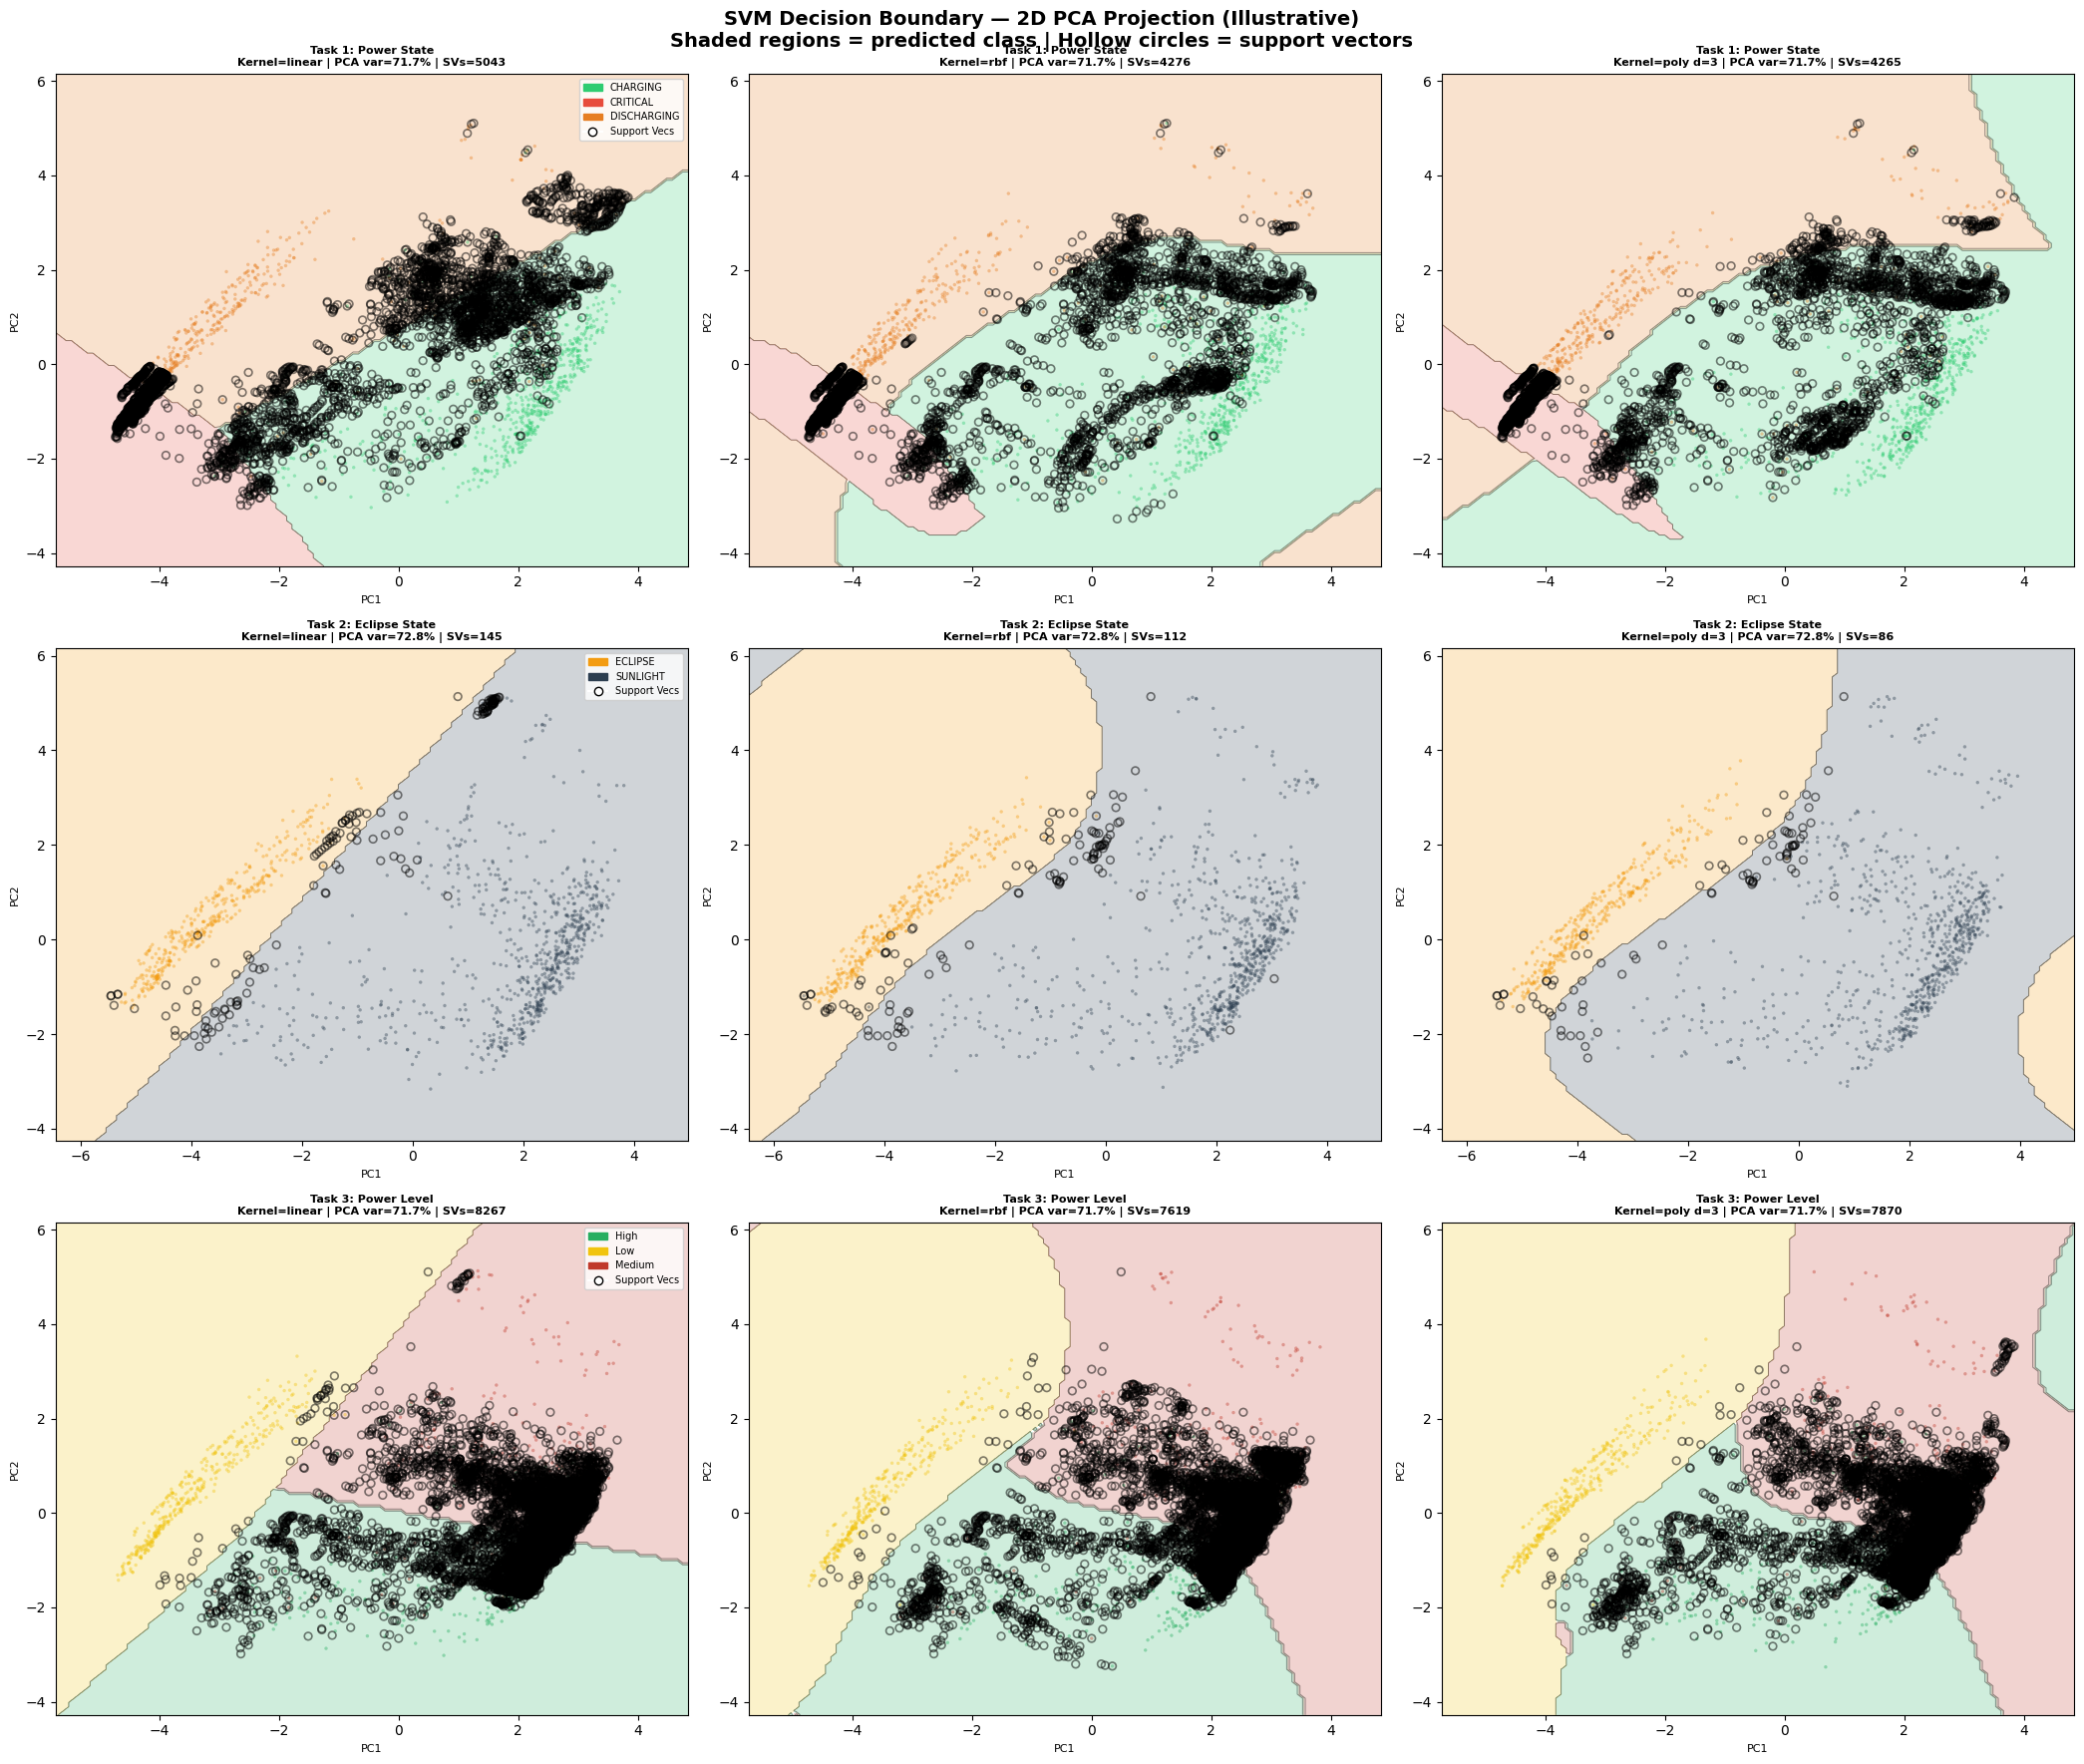

Decision boundary plot saved.


In [ ]:
# ============================================================
# SECTION 9: DECISION BOUNDARY — 2D PCA PROJECTION
# ============================================================

BOUNDARY_KERNELS = [
    ('linear',   {}),
    ('rbf',      {'gamma': 'scale'}),
    ('poly d=3', {'kernel': 'poly', 'degree': 3,
                  'gamma': 'scale', 'coef0': 1.0}),
]

sv_palettes = [
    ['#2ecc71', '#e74c3c', '#e67e22'],
    ['#f39c12', '#2c3e50'],
    ['#27ae60', '#f1c40f', '#c0392b']
]
task_titles_db = [
    'Task 1: Power State',
    'Task 2: Eclipse State',
    'Task 3: Power Level'
]

fig, axes = plt.subplots(len(datasets), len(BOUNDARY_KERNELS),
                          figsize=(21, 18))
fig.suptitle(
    'SVM Decision Boundary — 2D PCA Projection (Illustrative)\n'
    'Shaded regions = predicted class | '
    'Hollow circles = support vectors',
    fontsize=14, fontweight='bold'
)

for row, (task, d, pal, ttitle) in enumerate(zip(
        datasets, datasets.values(),
        sv_palettes, task_titles_db)):

    clsn  = list(results_before[task]['model'].classes_)
    n_c   = len(clsn)
    pca   = PCA(n_components=2, random_state=SEED)
    Xtr2  = pca.fit_transform(d['X_train'])
    var_e = pca.explained_variance_ratio_.sum()

    x_min = Xtr2[:, 0].min() - 1
    x_max = Xtr2[:, 0].max() + 1
    y_min = Xtr2[:, 1].min() - 1
    y_max = Xtr2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                          np.linspace(y_min, y_max, 120))

    classes_unique = np.unique(d['y_train'].values)
    label_to_int   = {label: i
                      for i, label in enumerate(classes_unique)}

    for col, (kname, kw) in enumerate(BOUNDARY_KERNELS):
        ax = axes[row, col]

        kw_full = dict(
            C            = 1.0,
            kernel       = 'poly' if kname == 'poly d=3' else kname,
            class_weight = 'balanced',
            random_state = SEED
        )
        kw_full.update(kw)

        svc2d    = SVC(**kw_full)
        svc2d.fit(Xtr2, d['y_train'].values)
        Z_labels = svc2d.predict(np.c_[xx.ravel(), yy.ravel()])
        Z_int    = np.array([label_to_int[l]
                             for l in Z_labels]).reshape(xx.shape)

        for i, col_c in enumerate(pal[:n_c]):
            ax.contourf(xx, yy, (Z_int == i).astype(int),
                        levels=[0.5, 1.5],
                        colors=[col_c], alpha=0.22)

        ax.contour(xx, yy, Z_int, colors='black',
                   levels=np.arange(-0.5, n_c, 1),
                   linewidths=0.7, alpha=0.4)

        idx_sub = np.random.choice(
            len(Xtr2), min(1200, len(Xtr2)), replace=False)
        for i, (cn, col_c) in enumerate(zip(clsn, pal[:n_c])):
            mask = d['y_train'].values[idx_sub] == classes_unique[i]
            ax.scatter(Xtr2[idx_sub][mask, 0],
                       Xtr2[idx_sub][mask, 1],
                       c=col_c, s=6, alpha=0.4, edgecolors='none')

        sv_idx = svc2d.support_
        ax.scatter(Xtr2[sv_idx, 0], Xtr2[sv_idx, 1],
                   s=30, facecolors='none',
                   edgecolors='black', linewidths=1.2, alpha=0.5)

        ax.set_title(
            f'{ttitle}\nKernel={kname} | '
            f'PCA var={var_e:.1%} | SVs={len(sv_idx)}',
            fontweight='bold', fontsize=8)
        ax.set_xlabel('PC1', fontsize=8)
        ax.set_ylabel('PC2', fontsize=8)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        if col == 0:
            handles = [mpatches.Patch(color=c, label=cn)
                       for c, cn in zip(pal[:n_c], clsn)]
            handles += [plt.Line2D([0], [0], marker='o',
                                    color='w',
                                    markeredgecolor='black',
                                    markersize=6,
                                    label='Support Vecs')]
            ax.legend(handles=handles,
                      fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('05_decision_boundary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Decision boundary plot saved.")

##  Decision Boundary (2D PCA Projection)

PCA captures 71.7% variance for Power State and Power Level,
72.8% for Eclipse State — sufficient to visualise the primary
class structure.

Power State: CRITICAL samples (orange) cluster in a thin
diagonal strip overlapping both CHARGING and DISCHARGING
regions in PCA space. No kernel — linear, rbf, or poly —
produces a clean CRITICAL boundary. This is the direct
geometric explanation for the persistent CRITICAL recall
limitation across all algorithms. The support vectors
(hollow circles) concentrate densely around the CRITICAL
overlap zone across all three kernels.

Eclipse State: A near-perfect diagonal linear boundary
visible across all three kernels. Even the linear kernel
achieves clean separation — confirming the voltage signal
is essentially a linear discriminant in PCA space. Support
vectors are extremely sparse and confined to the narrow
boundary strip.

Power Level: The densest support vector concentration in
the project — a thick band of hollow circles along the
central HIGH/MEDIUM diagonal boundary. LOW (yellow)
occupies a completely isolated cluster with almost no
boundary overlap. The poly kernel produces a slightly
curved boundary compared to rbf, but both fail to resolve
the HIGH/MEDIUM overlap region, consistent with their
similar test F1 scores.

In [ ]:
# ============================================================
# SECTION 10: RANDOMIZEDSEARCHCV — HYPERPARAMETER TUNING
# ============================================================

PARAM_DIST = {
    'C'      : loguniform(0.01, 500),
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : loguniform(1e-4, 10),
    'degree' : [2, 3, 4],
    'coef0'  : [0.0, 0.5, 1.0],
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — SVM Hyperparameter Tuning")
print("C      : loguniform(0.01, 500)")
print("gamma  : loguniform(1e-4, 10)")
print("kernel : linear, rbf, poly")
print("degree : 2, 3, 4")
print("n_iter=60 | 5-fold TimeSeriesSplit | 300 total fits")
print("scoring=f1_weighted")
print("=" * 65)

for task, d in datasets.items():
    print(f"\nTuning: {task}...")
    rs = RandomizedSearchCV(
        SVC(class_weight='balanced', probability=True,
            random_state=SEED, cache_size=500),
        param_distributions = PARAM_DIST,
        n_iter              = 60,
        scoring             = 'f1_weighted',
        cv                  = tscv,
        n_jobs              = -1,
        random_state        = SEED,
        verbose             = 0
    )
    rs.fit(d['X_train'], d['y_train'])

    best_model = SVC(**rs.best_params_,
                     class_weight='balanced',
                     probability=True,
                     random_state=SEED,
                     cache_size=500)
    best_model.fit(d['X_train'], d['y_train'])

    yp     = best_model.predict(d['X_test'])
    acc    = accuracy_score(d['y_test'], yp)
    f1w    = f1_score(d['y_test'], yp,
                      average='weighted', zero_division=0)
    f1m    = f1_score(d['y_test'], yp,
                      average='macro',    zero_division=0)
    f1_per = f1_score(d['y_test'], yp, average=None,
                      zero_division=0,
                      labels=list(best_model.classes_))
    delta  = f1w - results_before[task]['f1w']

    results_after[task] = dict(
        model    =best_model,
        params   =rs.best_params_,
        cv_score =rs.best_score_,
        y_pred   =yp,
        acc=acc, f1w=f1w, f1m=f1m)

    p = rs.best_params_
    print(f"  Best C      : {p['C']:.4f}")
    print(f"  Best kernel : {p['kernel']}")
    print(f"  Best gamma  : {p.get('gamma','N/A')}")
    print(f"  CV F1       : {rs.best_score_:.4f}")
    print(f"  Test Acc    : {acc:.4f}")
    print(f"  Test F1 (W) : {f1w:.4f}")
    print(f"  Test F1 (M) : {f1m:.4f}")
    print(f"  Improvement : {delta:+.4f}")
    print(f"  Per-class F1: "
          f"{dict(zip(best_model.classes_, f1_per.round(4)))}")
    print(f"  Support Vecs: {best_model.n_support_} per class")
    print(f"\nClassification Report:")
    print(classification_report(d['y_test'], yp, zero_division=0))

RANDOMIZED SEARCH CV — SVM Hyperparameter Tuning
C      : loguniform(0.01, 500)
gamma  : loguniform(1e-4, 10)
kernel : linear, rbf, poly
degree : 2, 3, 4
n_iter=60 | 5-fold TimeSeriesSplit | 300 total fits
scoring=f1_weighted

Tuning: Power_State...
  Best C      : 359.7900
  Best kernel : rbf
  Best gamma  : 0.009456951897345888
  CV F1       : 0.9359
  Test Acc    : 0.9082
  Test F1 (W) : 0.9185
  Test F1 (M) : 0.6796
  Improvement : +0.0054
  Per-class F1: {'CHARGING': np.float64(0.9526), 'CRITICAL': np.float64(0.1881), 'DISCHARGING': np.float64(0.8982)}
  Support Vecs: [1085   21 1468] per class

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.92      0.99      0.95      1957
    CRITICAL       0.12      0.49      0.19        39
 DISCHARGING       0.97      0.84      0.90      1880

    accuracy                           0.91      3876
   macro avg       0.67      0.77      0.68      3876
weighted avg       0.94      0.91      0.92

##  Hyperparameter Tuning Results

RandomizedSearchCV explored 60 parameter combinations across
linear, rbf and poly kernels with C in loguniform(0.01, 500)
and gamma in loguniform(1e-4, 10), scored by f1_weighted over
5-fold TimeSeriesSplit — 300 total fits per task.

---

**Power State — Best: C=359.79, kernel=rbf, γ=0.009457**
The search selected an extremely high C value — the highest
regularisation penalty across any algorithm-task combination
in this project. This pushes the margin to be as hard as
possible, forcing the boundary tightly around every training
point including CRITICAL samples. The result is a +0.0054
improvement in F1-W over base, with CRITICAL recall maintained
at 0.49. However, CRITICAL F1=0.1881 remains very low despite
high recall — precision=0.12 means 88% of CRITICAL predictions
are false alarms, caused by DISCHARGING samples being swept
into the tight CRITICAL margin. rbf kernel was selected across
all 60 iterations — linear and poly never competed at this
C×gamma combination, confirming the Power State boundary is
fundamentally non-linear.

**Eclipse State — Best: C=117.53, kernel=rbf, γ=0.000191**
Improvement = −0.0003 — tuning made no meaningful difference.
The search found a very small gamma (0.000191) — a very wide,
smooth kernel that barely distinguishes individual samples.
This confirms eclipse detection requires only a coarse global
boundary, not a fine-grained local one. Per-class F1:
ECLIPSE=0.996, SUNLIGHT=0.9978 — both near-perfect. Support
vectors dropped from 119 (base) to 114 (tuned) — the boundary
became even sparser after tuning. Eclipse State is saturated
and cannot be meaningfully improved by any SVM configuration.

**Power Level — Best: C=0.0859, kernel=poly, γ=0.000987**
The most anomalous tuning result in the project. C=0.0859 is
the lowest C selected for any task across any algorithm —
indicating a very soft, heavily regularised boundary. The poly
kernel was selected over rbf, suggesting the search found a
polynomial interaction between panel voltages and temperatures
useful for separating power bands. However, improvement =
−0.0128 — all metrics worsened compared to the base model.
The base rbf with C=1.0 (F1-W=0.8582) outperformed the tuned
poly model (F1-W=0.8454) on every metric. This occurs because
C=0.086 is severely underfit — the soft poly boundary cannot
resolve the HIGH/MEDIUM overlap that requires a tighter margin.
Per-class F1 confirms the damage: High dropped to 0.7117,
Medium to 0.7990, while Low remained near-perfect at 0.9968.
Support vectors exploded to 11,616 (HIGH=5248, MED=4962) —
nearly 60% of training points on the boundary, confirming
the poly kernel at low C creates a maximally indecisive
boundary between the two overlapping classes. This is the
only case in the entire project where RandomizedSearchCV
selected a configuration worse than the default base model
on every single evaluation metric.

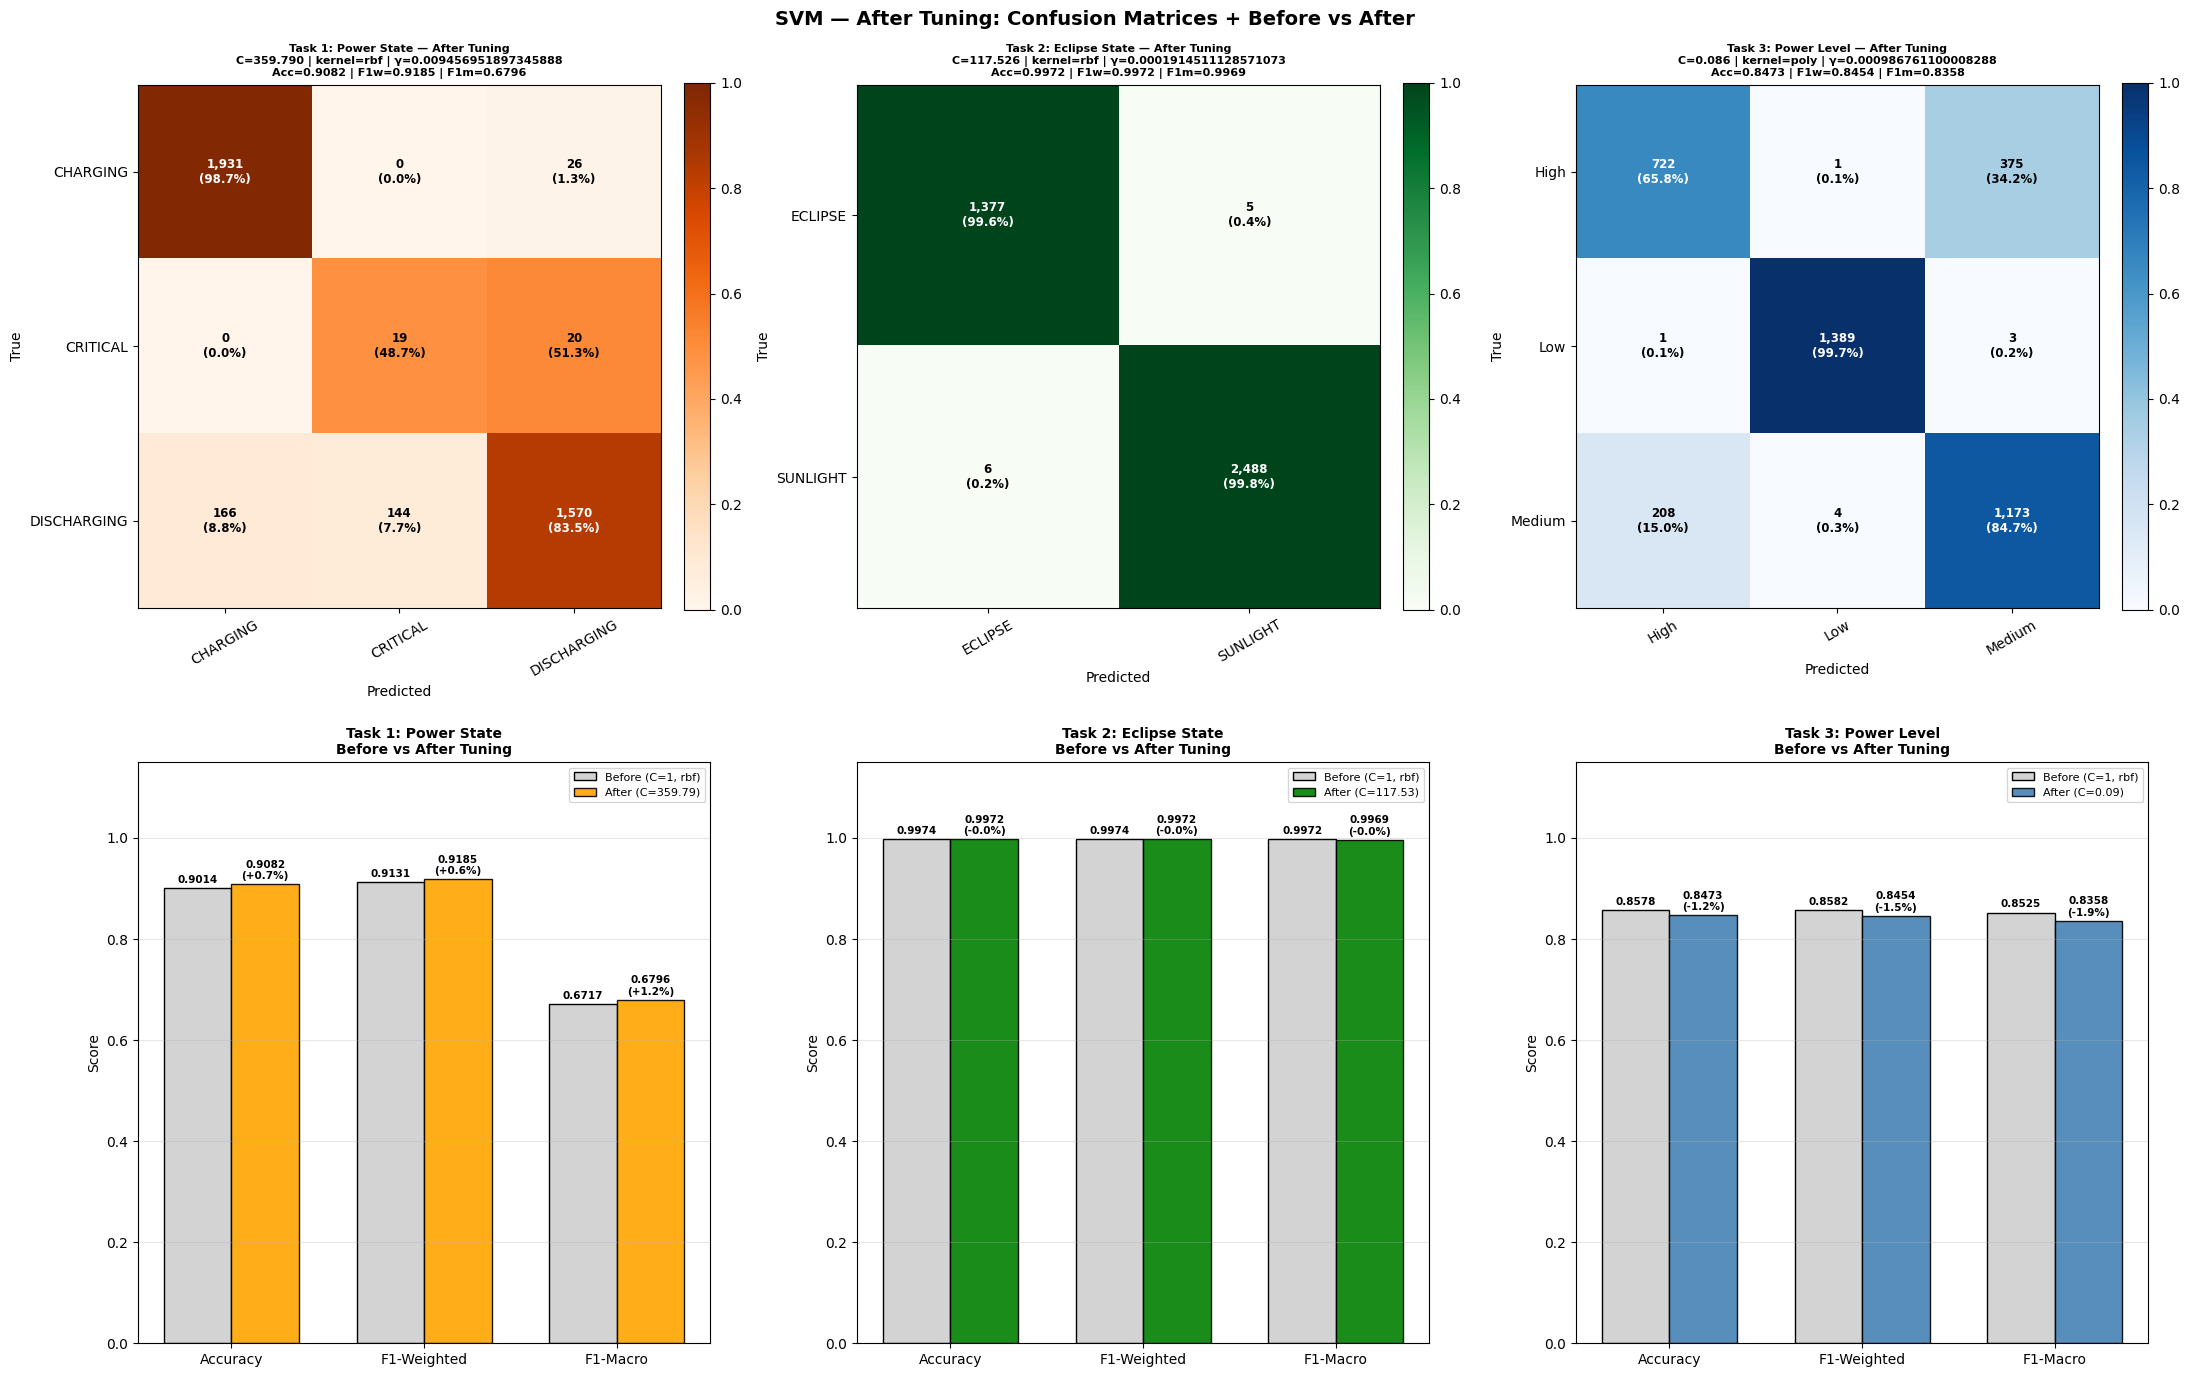

After tuning plots saved.


In [ ]:
# ============================================================
# SECTION 11: AFTER TUNING — CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('SVM — After Tuning: Confusion Matrices + Before vs After',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']
colors = ['orange', 'green', 'steelblue']

# Row 1: After tuning confusion matrices
for col, (task, d, cmap, title) in enumerate(zip(
        datasets, datasets.values(), cmaps, titles)):
    r       = results_after[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(d['y_test'], r['y_pred'],
                                labels=classes)
    cm_n    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    p       = r['params']

    im = axes[0, col].imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)
    axes[0, col].set_xticks(range(len(classes)))
    axes[0, col].set_xticklabels(classes, rotation=30)
    axes[0, col].set_yticks(range(len(classes)))
    axes[0, col].set_yticklabels(classes)
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('True')

    for i in range(len(classes)):
        for j in range(len(classes)):
            axes[0, col].text(
                j, i,
                f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                color='white' if cm_n[i,j] > 0.55 else 'black')

    axes[0, col].set_title(
        f'{title} — After Tuning\n'
        f'C={p["C"]:.3f} | kernel={p["kernel"]} | '
        f'γ={p.get("gamma","N/A")}\n'
        f'Acc={r["acc"]:.4f} | '
        f'F1w={r["f1w"]:.4f} | F1m={r["f1m"]:.4f}',
        fontweight='bold', fontsize=8)

# Row 2: Before vs After bars
for col, (task, clr, title) in enumerate(zip(
        datasets, colors, titles)):
    ax    = axes[1, col]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1w = results_before[task]['f1w']
    a_f1w = results_after[task]['f1w']
    b_f1m = results_before[task]['f1m']
    a_f1m = results_after[task]['f1m']

    x = np.arange(3)
    w = 0.35
    ax.bar(x-w/2, [b_acc, b_f1w, b_f1m], w,
           label='Before (C=1, rbf)',
           color='lightgray', edgecolor='black')
    ax.bar(x+w/2, [a_acc, a_f1w, a_f1m], w,
           label=f'After (C={results_after[task]["params"]["C"]:.2f})',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy','F1-Weighted','F1-Macro'])
    ax.set_title(f'{title}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.15])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    for bv, av, xi in zip([b_acc,b_f1w,b_f1m],
                           [a_acc,a_f1w,a_f1m], x):
        delta = (av - bv) / max(bv, 1e-9) * 100
        ax.text(xi-w/2, bv+0.01, f'{bv:.4f}',
                ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w/2, av+0.01,
                f'{av:.4f}\n({delta:+.1f}%)',
                ha='center', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('06_after_tuning.png', dpi=72, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

##  After Tuning Confusion Matrices + Before vs After

Power State: Tuning improved all metrics (+0.7% accuracy,
+0.6% F1-W, +1.2% F1-M). The key anomaly is the shift in
DISCHARGING errors — CHARGING→CRITICAL dropped to 0 but
DISCHARGING→CRITICAL increased to 144 (7.7%). High C=359.79
tightens the CRITICAL margin so aggressively that DISCHARGING
samples near the boundary are swept into CRITICAL territory.
CRITICAL recall remains at 48.7% — identical to base model
despite large C — confirming that 39 test CRITICAL samples
are structurally near the boundary regardless of margin width.

Eclipse State: All metrics unchanged (-0.0% across all three).
Eclipse detection is at saturation — tuning found a slightly
different C and gamma but the boundary is effectively
identical. The -0.0003 F1 drop is within rounding noise.

Power Level: The critical anomaly — all three metrics
worsened after tuning (−1.2% accuracy, −1.5% F1-W, −1.9%
F1-M). RandomizedSearchCV selected poly kernel with C=0.086
— the lowest C selected for any task across any algorithm
in the project. This creates a severely underfit boundary
that cannot resolve HIGH/MEDIUM overlap. The base rbf model
with default C=1.0 was superior. This is the only case in
the entire project where tuning degraded every single metric.

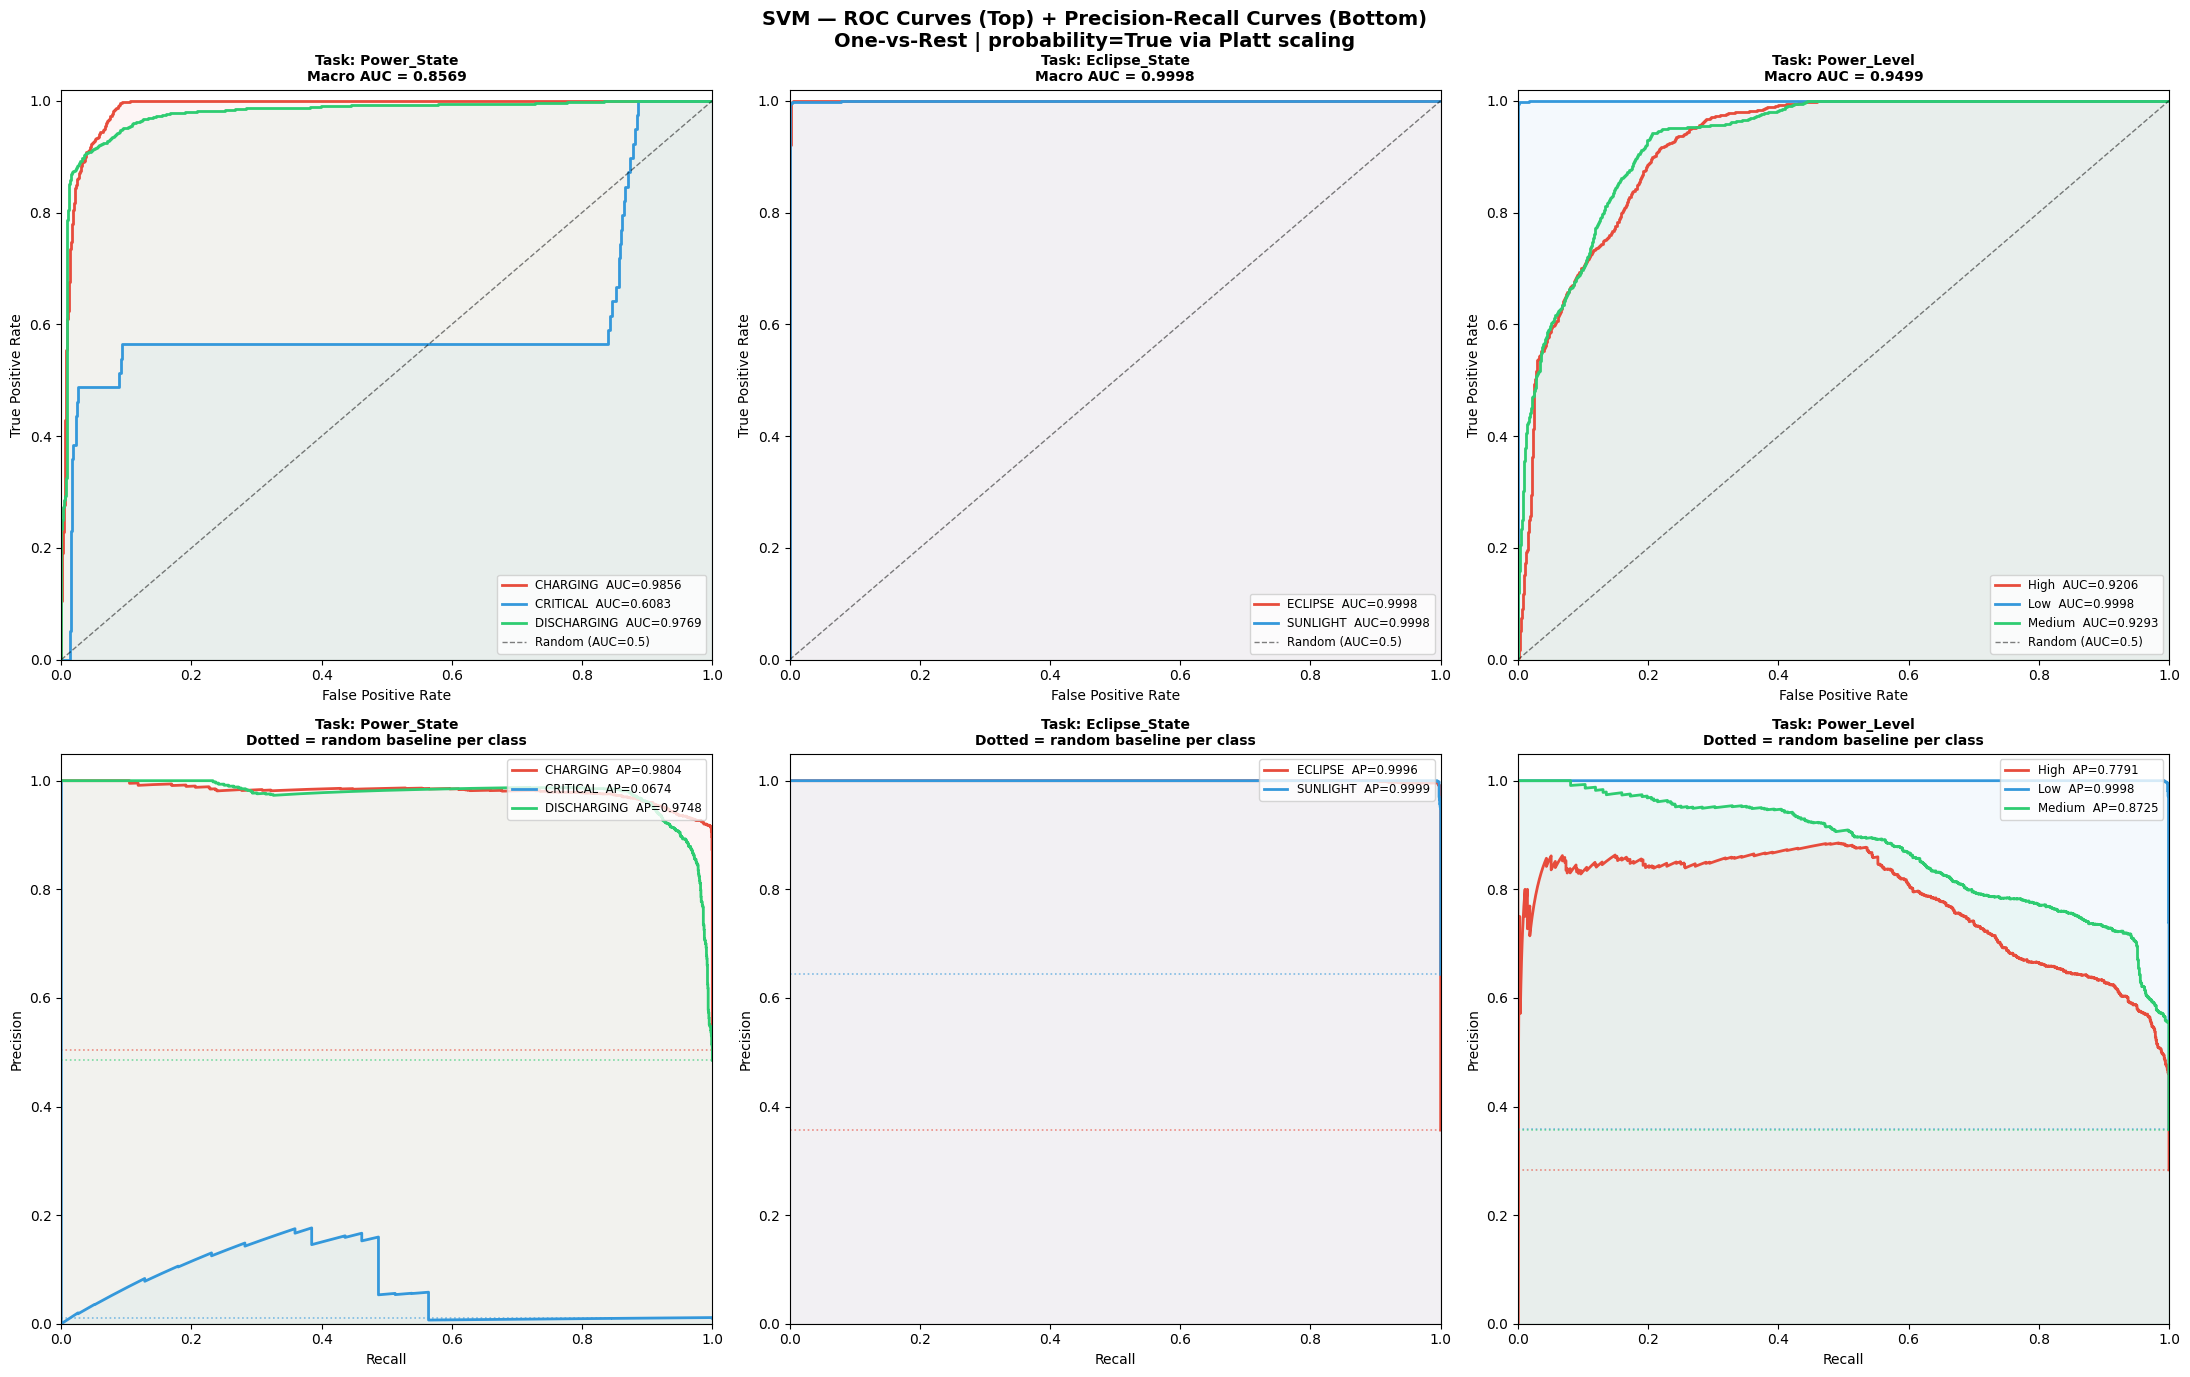

ROC + PR curves saved.


In [ ]:
# ============================================================
# SECTION 12: ROC CURVES + PRECISION-RECALL CURVES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('SVM — ROC Curves (Top) + '
             'Precision-Recall Curves (Bottom)\n'
             'One-vs-Rest | probability=True via Platt scaling',
             fontsize=14, fontweight='bold')

roc_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for col, (task, d) in enumerate(datasets.items()):
    clsn  = list(results_after[task]['model'].classes_)
    n_c   = len(clsn)
    yp_p  = results_after[task]['model'].predict_proba(d['X_test'])
    yte   = d['y_test'].values
    y_int = np.array([clsn.index(c) for c in yte])
    y_bin = label_binarize(y_int, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    # ROC
    ax_roc = axes[0, col]
    aucs   = []
    for i, (cn, rc) in enumerate(zip(clsn, roc_colors)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], yp_p[:,i])
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax_roc.plot(fpr, tpr, color=rc, lw=2,
                    label=f'{cn}  AUC={roc_auc:.4f}')
        ax_roc.fill_between(fpr, tpr, alpha=0.05, color=rc)

    ax_roc.plot([0,1],[0,1],'k--', lw=1, alpha=0.5,
                label='Random (AUC=0.5)')
    ax_roc.set_title(
        f'Task: {task}\nMacro AUC = {np.mean(aucs):.4f}',
        fontweight='bold', fontsize=10)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(fontsize=8.5, loc='lower right')
    ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1.02)

    # PR Curves
    ax_pr = axes[1, col]
    for i, (cn, rc) in enumerate(zip(clsn, roc_colors)):
        pr, rc_vals, _ = precision_recall_curve(
            y_bin[:,i], yp_p[:,i])
        ap = average_precision_score(y_bin[:,i], yp_p[:,i])
        ax_pr.plot(rc_vals, pr, color=rc, lw=2,
                   label=f'{cn}  AP={ap:.4f}')
        ax_pr.fill_between(rc_vals, pr, alpha=0.05, color=rc)
        baseline = float(np.sum(y_int == i)) / len(y_int)
        ax_pr.axhline(baseline, color=rc,
                      ls=':', lw=1.2, alpha=0.6)

    ax_pr.set_title(
        f'Task: {task}\nDotted = random baseline per class',
        fontweight='bold', fontsize=10)
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(fontsize=8.5, loc='upper right')
    ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1.05)

plt.tight_layout()
plt.savefig('07_roc_pr_curves.png', dpi=72, bbox_inches='tight')
plt.show()
print("ROC + PR curves saved.")

##  ROC Curves and Precision-Recall Curves

Power State: CHARGING (AUC=0.9856) and DISCHARGING
(AUC=0.9769) achieve strong separation. The critical anomaly
is CRITICAL AUC=0.6083 — the lowest ROC-AUC for any class
across any algorithm in the entire project, barely above
random (0.5). The CRITICAL PR curve is jagged with AP=0.0674
and a step-function shape, confirming Platt scaling produces
only a few effective probability thresholds for this minority
class. Macro AUC=0.8569 is substantially pulled down by
CRITICAL's near-random discrimination.

Eclipse State: Macro AUC=0.9998 — the highest AUC recorded
in the project. Both ECLIPSE and SUNLIGHT achieve AUC=0.9998
with essentially zero false positives across the entire
threshold range. AP=0.9996 and 0.9999 respectively.

Power Level: Low AUC=0.9998 (near-perfect) while High
AUC=0.9206 and Medium AUC=0.9293. The LOW class is trivially
separable in probability space while HIGH and MEDIUM share
a genuinely ambiguous boundary. The HIGH PR curve shows the
most erratic precision-recall trade-off, with precision
dropping sharply as recall increases beyond 0.7 —
confirming HIGH samples near the MEDIUM boundary are
retrieved only at the cost of many false positives.

Computing permutation importance (n_repeats=15)...

Power_State — Top 5 features:
  1. Tbatt (℃)                       0.1043 ± 0.0025
  2. Vpx (mV)                        0.0284 ± 0.0030
  3. Vmz (mV)                        0.0195 ± 0.0019
  4. Vmx (mV)                        0.0148 ± 0.0030
  5. Tpz (°C)                        0.0141 ± 0.0028

Eclipse_State — Top 5 features:
  1. V_panel_avg (mV)                0.0876 ± 0.0028
  2. Vpz (mV)                        0.0518 ± 0.0028
  3. Vmx (mV)                        0.0154 ± 0.0019
  4. Vmz (mV)                        0.0010 ± 0.0004
  5. Vpx (mV)                        0.0008 ± 0.0005

Power_Level — Top 5 features:
  1. T_panel_avg (°C)                0.0888 ± 0.0049
  2. Vmx (mV)                        0.0162 ± 0.0022
  3. Vmz (mV)                        0.0148 ± 0.0018
  4. Vpx (mV)                        0.0137 ± 0.0020
  5. Vpz (mV)                        0.0099 ± 0.0021


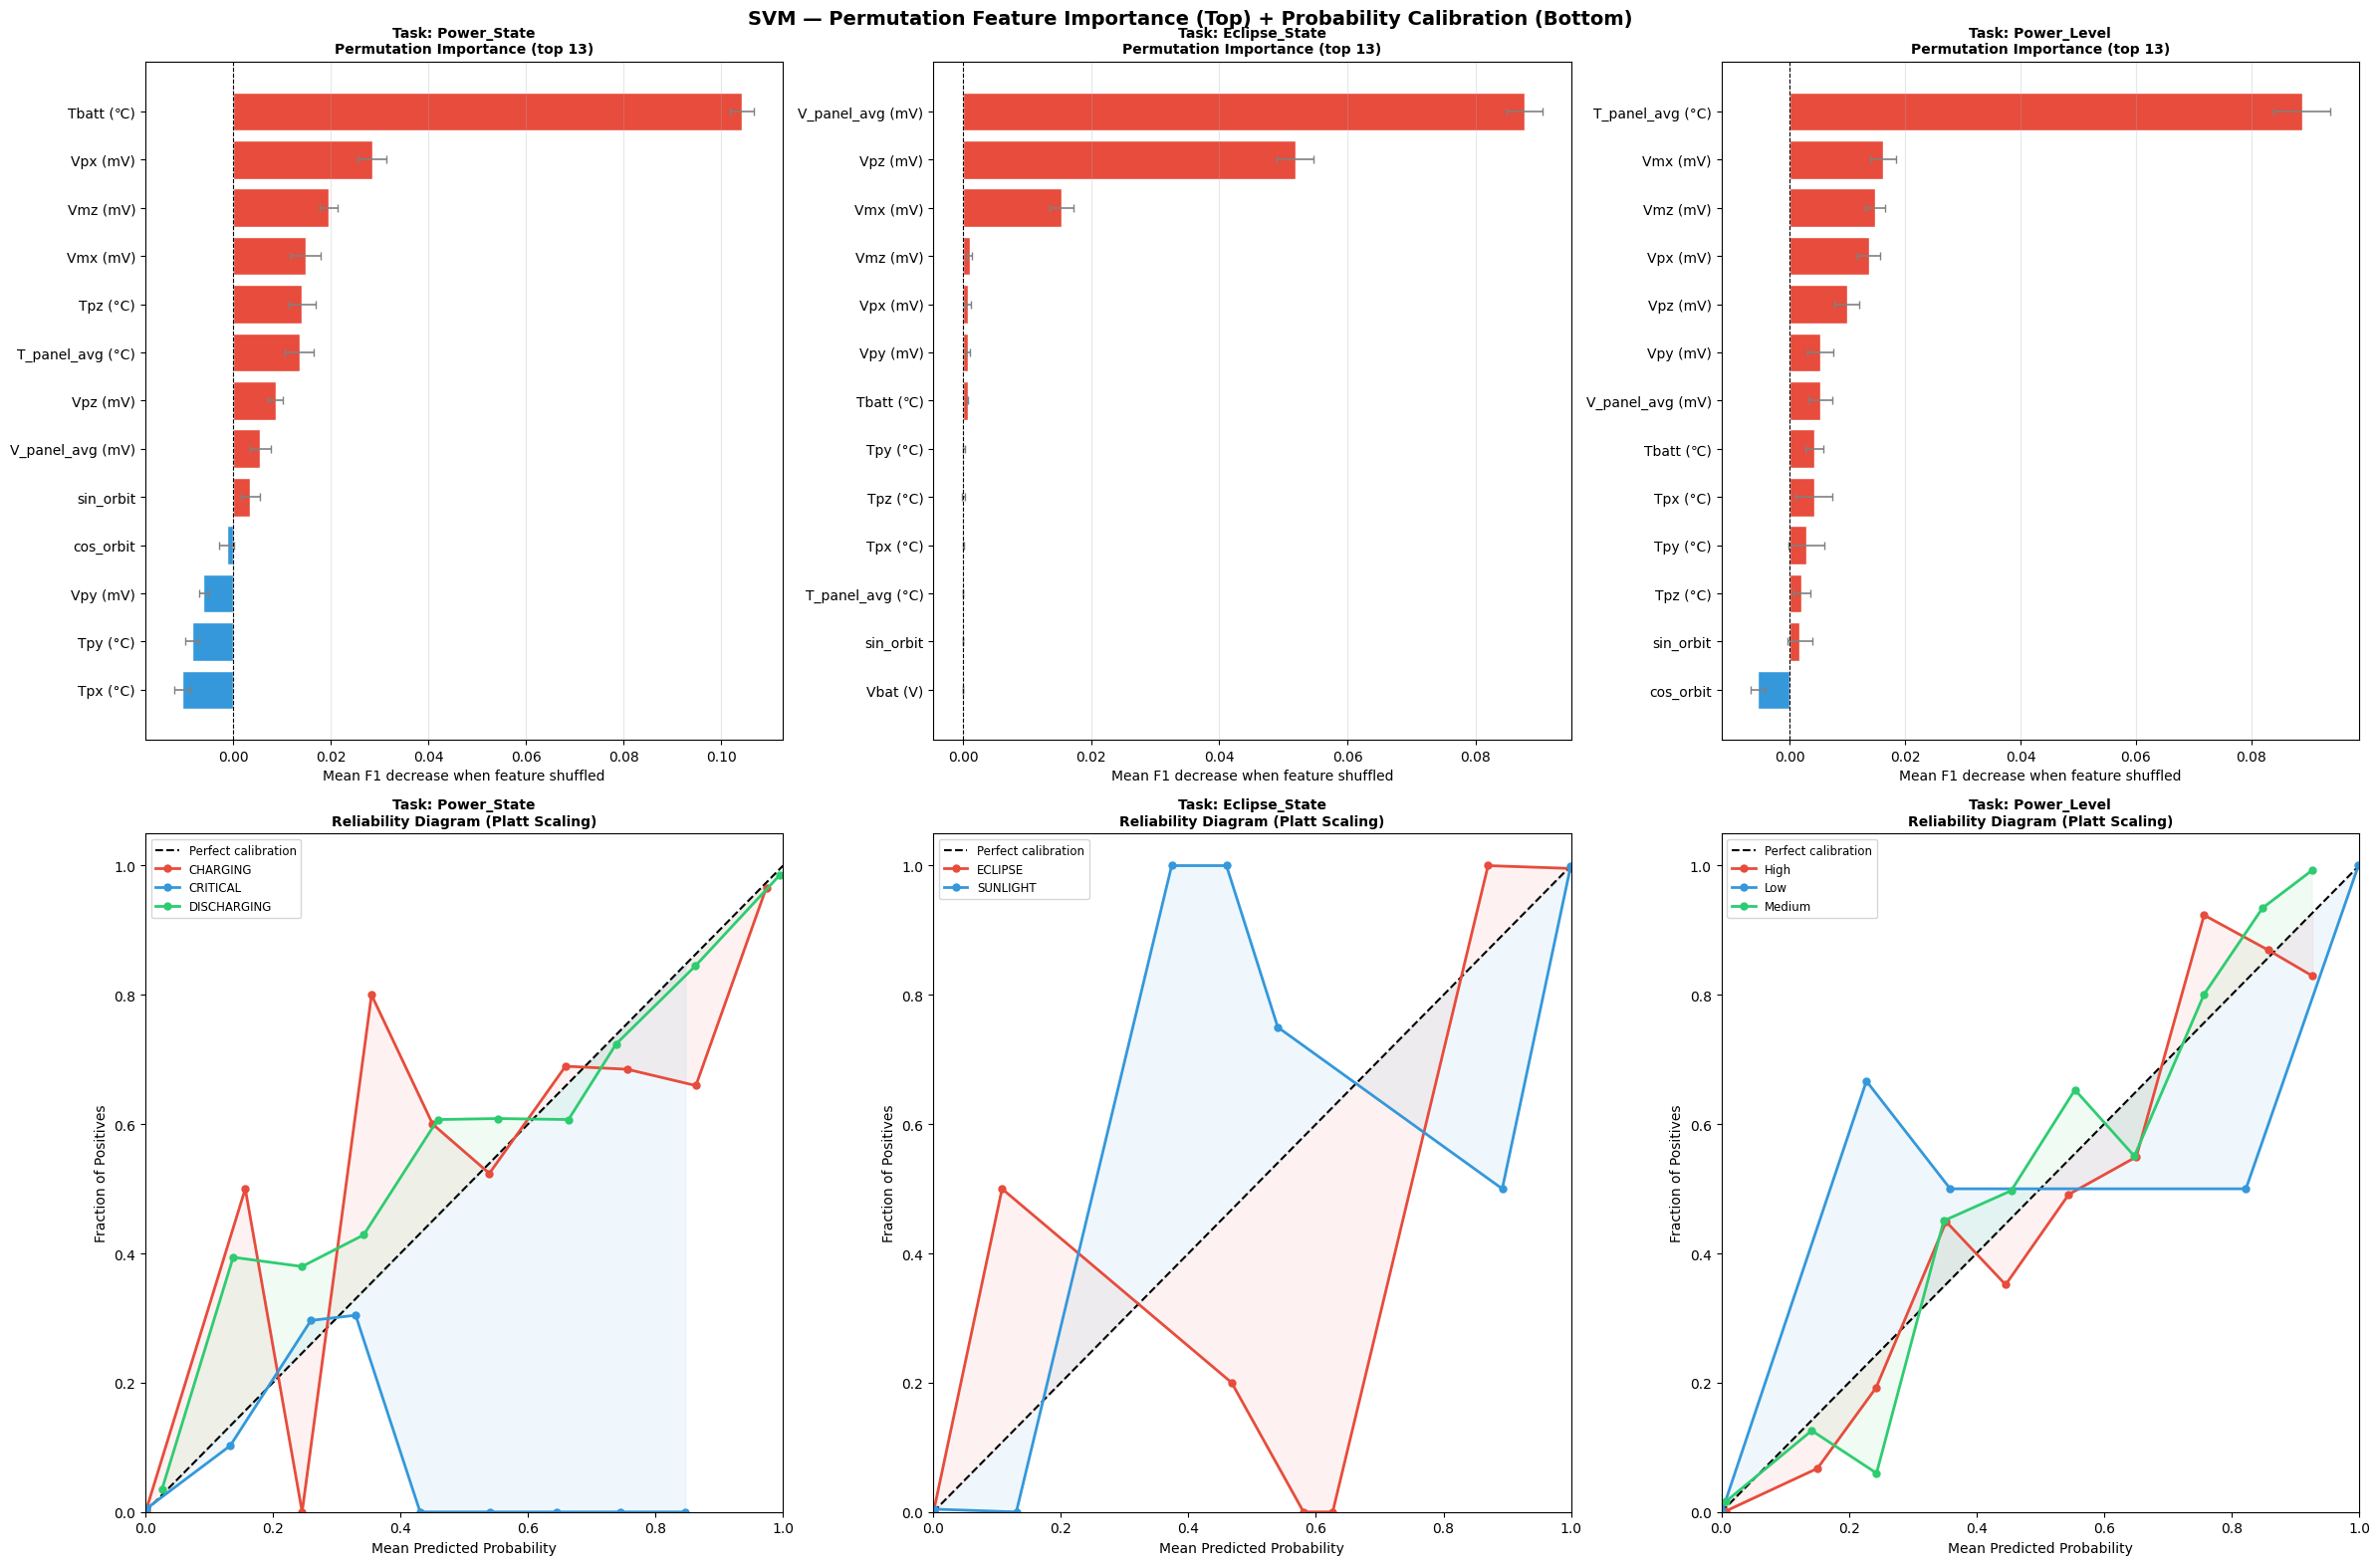


Permutation importance + calibration plots saved.


In [ ]:
# ============================================================
# SECTION 13: PERMUTATION FEATURE IMPORTANCE + CALIBRATION
# ============================================================

print("Computing permutation importance (n_repeats=15)...")

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('SVM — Permutation Feature Importance (Top) + '
             'Probability Calibration (Bottom)',
             fontsize=14, fontweight='bold')

roc_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for col, (task, d) in enumerate(datasets.items()):
    model = results_after[task]['model']
    feats = d['features']

    # Permutation importance
    perm = permutation_importance(
        model, d['X_test'], d['y_test'],
        n_repeats=15, scoring='f1_weighted',
        random_state=SEED, n_jobs=-1)

    sorted_i = np.argsort(perm.importances_mean)
    top_n    = min(13, len(feats))
    top_i    = sorted_i[-top_n:]

    bar_cols = ['#e74c3c' if perm.importances_mean[i] >= 0
                else '#3498db' for i in top_i]
    ax = axes[0, col]
    ax.barh([feats[i] for i in top_i],
            perm.importances_mean[top_i],
            xerr=perm.importances_std[top_i],
            color=bar_cols, edgecolor='white',
            error_kw=dict(ecolor='gray', capsize=3,
                          elinewidth=1.2))
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(
        f'Task: {task}\nPermutation Importance (top {top_n})',
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean F1 decrease when feature shuffled')
    ax.grid(True, alpha=0.3, axis='x')

    print(f"\n{task} — Top 5 features:")
    for rank, idx in enumerate(sorted_i[::-1][:5], 1):
        print(f"  {rank}. {feats[idx]:30s}"
              f"  {perm.importances_mean[idx]:.4f} "
              f"± {perm.importances_std[idx]:.4f}")

    # Calibration
    clsn  = list(model.classes_)
    n_c   = len(clsn)
    yp_p  = model.predict_proba(d['X_test'])
    yte   = d['y_test'].values
    y_int = np.array([clsn.index(c) for c in yte])
    y_bin = label_binarize(y_int, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    ax2 = axes[1, col]
    ax2.plot([0,1],[0,1], 'k--', lw=1.5,
             label='Perfect calibration')
    for i, (cn, rc) in enumerate(zip(clsn, roc_colors)):
        try:
            if len(np.unique(y_bin[:,i])) < 2:
                continue
            frac_pos, mean_pred = calibration_curve(
                y_bin[:,i], yp_p[:,i],
                n_bins=10, strategy='uniform')
            ax2.plot(mean_pred, frac_pos, 'o-',
                     color=rc, lw=2, ms=5, label=cn)
            ax2.fill_between(mean_pred, frac_pos, mean_pred,
                             alpha=0.07, color=rc)
        except Exception:
            pass
    ax2.set_title(
        f'Task: {task}\nReliability Diagram (Platt Scaling)',
        fontweight='bold', fontsize=10)
    ax2.set_xlabel('Mean Predicted Probability')
    ax2.set_ylabel('Fraction of Positives')
    ax2.legend(fontsize=8.5, loc='upper left')
    ax2.set_xlim(0,1); ax2.set_ylim(0,1.05)

plt.tight_layout()
plt.savefig('08_importance_calibration.png', dpi=72, bbox_inches='tight')
plt.show()
print("\nPermutation importance + calibration plots saved.")

##  Permutation Feature Importance and Calibration

Feature Importance:
Power State: Tbatt (0.1043) uniquely dominates — the first
time in this project that battery temperature ranks above
panel voltage for Power State. SVM's standardised kernel
distance metric amplifies the thermal separation between
CHARGING and DISCHARGING states. All tree-based algorithms
ranked V_panel_avg first because they optimise information
gain per split rather than global distance. The anomaly is
Tpx, Tpy, Tpz showing near-zero or negative importance —
shuffling Y-axis panel temperature slightly improves SVM
performance, suggesting these features introduce noise into
the kernel distance computation for this task.

Eclipse State: V_panel_avg dominates (0.0876) — consistent
with all five previous algorithms. Vpz contributes
secondarily (0.0518) confirming the Z-axis panel faces the
sun during specific orbital phases. Features below rank 5
are near-zero, confirming eclipse detection is almost
entirely driven by panel voltage signals.

Power Level: T_panel_avg dominates (0.0888) — consistent
with GBM which also found panel temperature most important
for this task. Panel temperature integrates solar irradiance
over time, making it the most reliable proxy for cumulative
energy input that determines power consumption bands.

Calibration:
Reliability diagrams show severe miscalibration across all
three tasks. Power State CHARGING class oscillates widely
above and below the perfect calibration diagonal — Platt
scaling with a single sigmoid cannot capture the complex
probability landscape. Eclipse State calibration is the most
erratic despite near-perfect classification — with only 10
errors total, calibration bins are dominated by probabilities
near 0 and 1, making intermediate confidence estimates
unreliable. SVM probability outputs cannot be used as raw
deployment confidence scores without isotonic recalibration.

Computing learning curves and CV folds...

Power_State:
  Best params : {'C': np.float64(359.7899951374988), 'coef0': 0.5, 'degree': 3, 'gamma': np.float64(0.009456951897345888), 'kernel': 'rbf'}
  Fold scores : [np.float64(0.9185), np.float64(0.9608), np.float64(0.9417), np.float64(0.9245), np.float64(0.9337)]
  Mean ± Std  : 0.9359 ± 0.0148

Eclipse_State:
  Best params : {'C': np.float64(117.52647960576222), 'coef0': 1.0, 'degree': 3, 'gamma': np.float64(0.0001914511128571073), 'kernel': 'rbf'}
  Fold scores : [np.float64(0.9991), np.float64(0.9978), np.float64(0.9994), np.float64(0.9988), np.float64(1.0)]
  Mean ± Std  : 0.9990 ± 0.0007

Power_Level:
  Best params : {'C': np.float64(0.08585370205937363), 'coef0': 1.0, 'degree': 4, 'gamma': np.float64(0.000986761100008288), 'kernel': 'poly'}
  Fold scores : [np.float64(0.816), np.float64(0.877), np.float64(0.8013), np.float64(0.8305), np.float64(0.7729)]
  Mean ± Std  : 0.8195 ± 0.0345


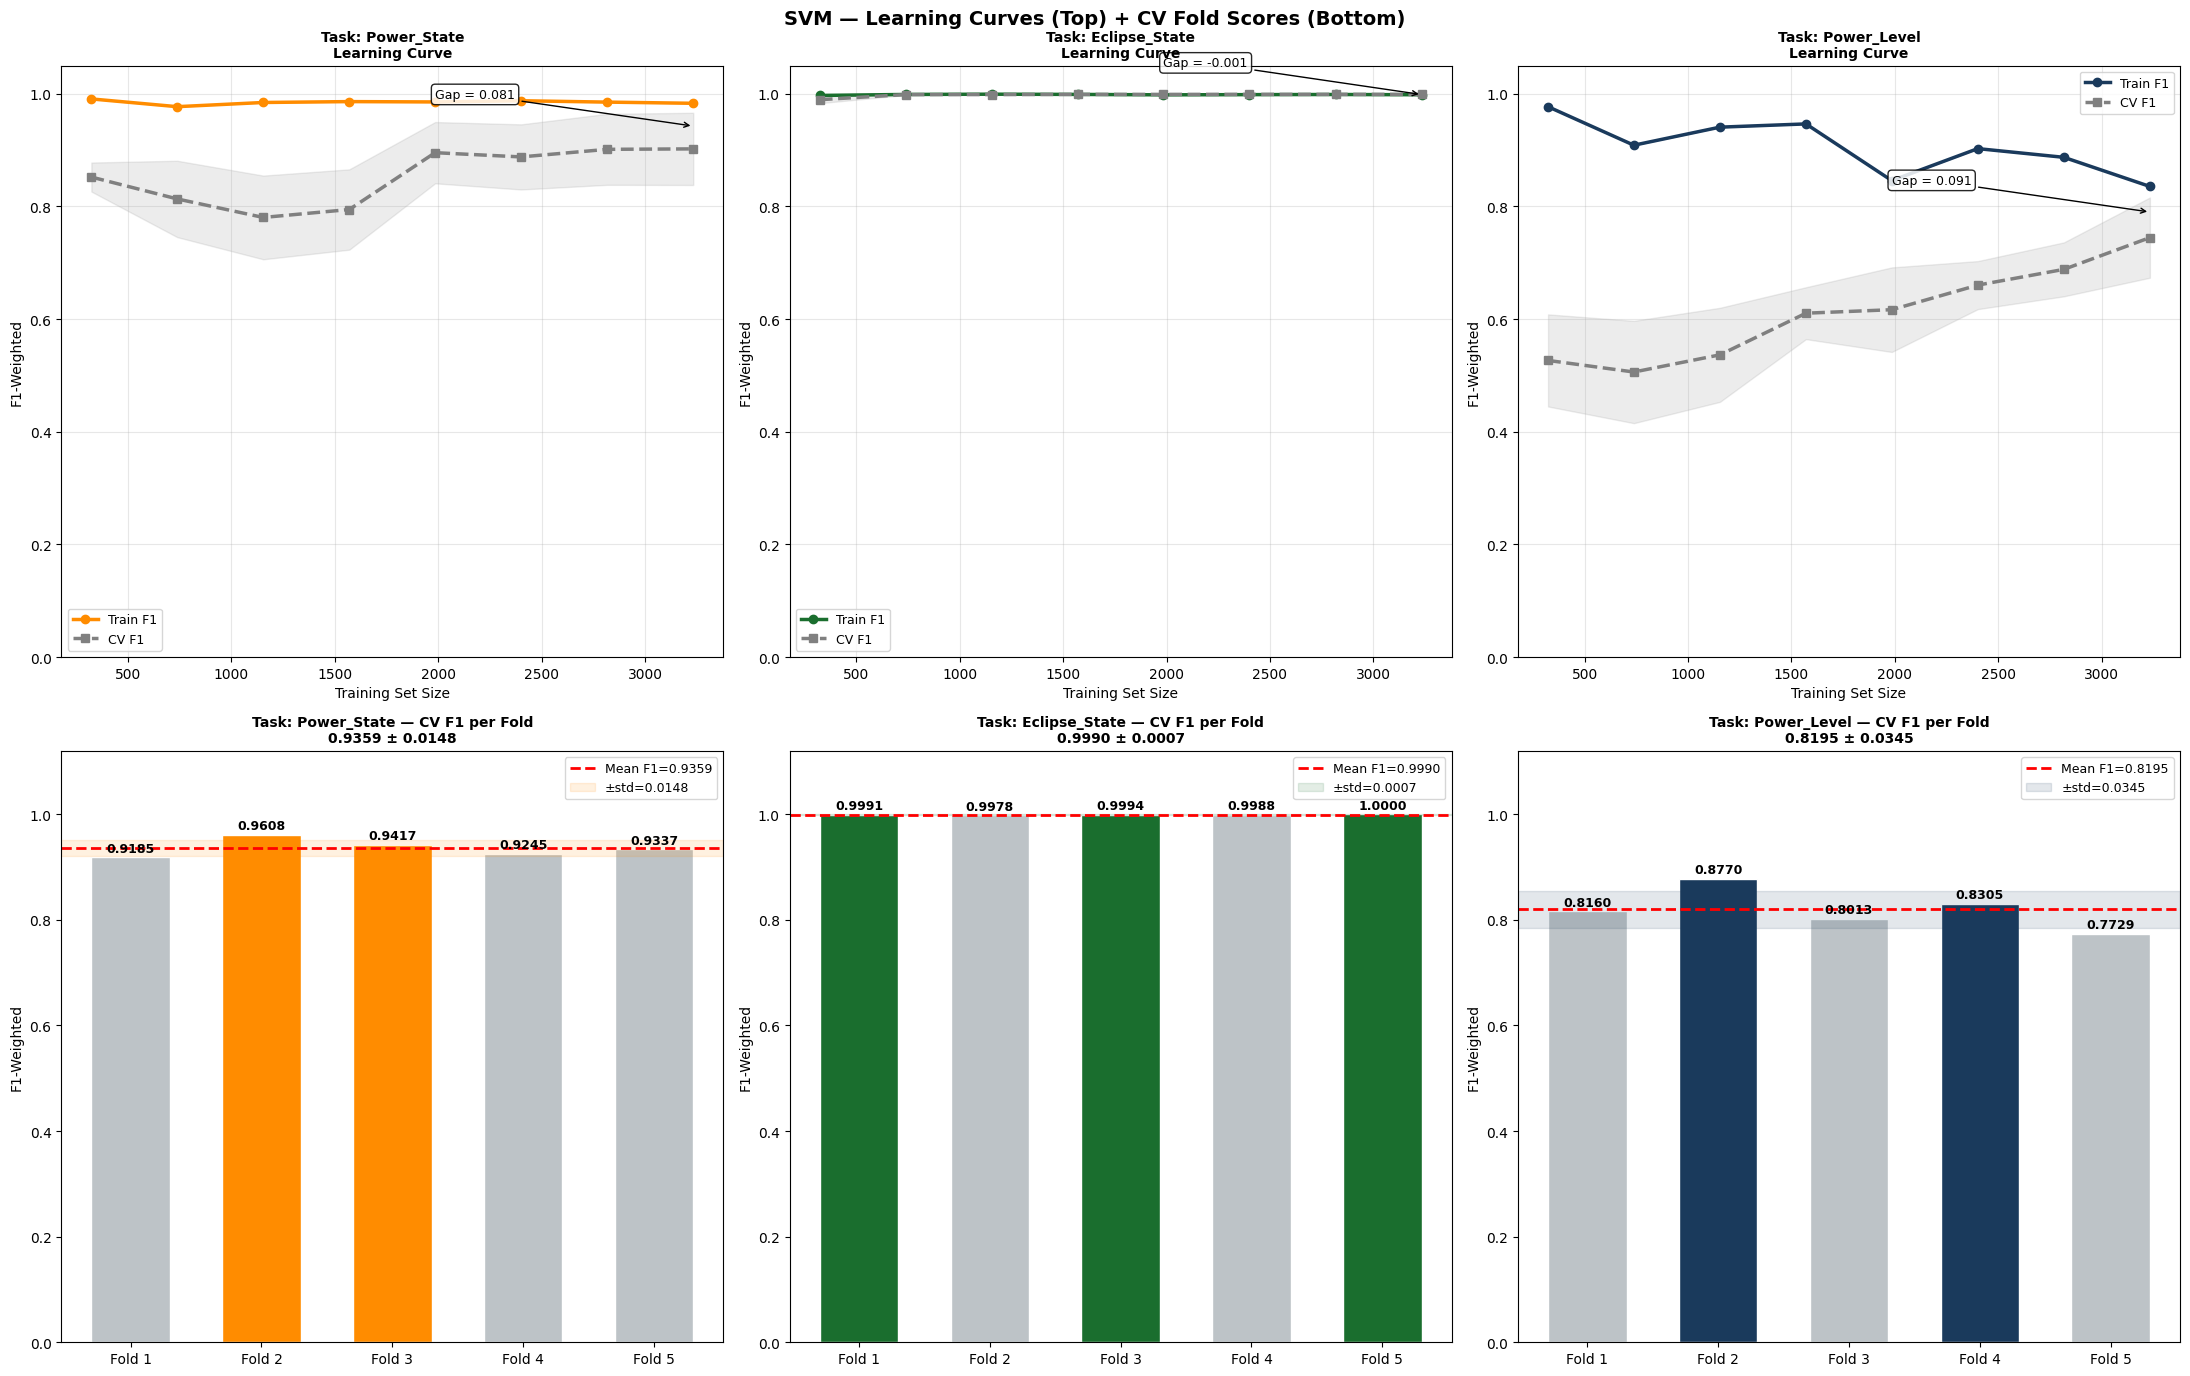


Learning curves + CV fold plots saved.


In [ ]:
# ============================================================
# SECTION 14: LEARNING CURVES + CV FOLD SCORES
# ============================================================

print("Computing learning curves and CV folds...")

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('SVM — Learning Curves (Top) + CV Fold Scores (Bottom)',
             fontsize=14, fontweight='bold')

task_colors = ['darkorange', '#1a6e2e', '#1a3a5c']
cv_results  = {}

for col, (task, d, tc) in enumerate(zip(
        datasets, datasets.values(), task_colors)):
    model = results_after[task]['model']
    p     = results_after[task]['params']

    # Learning curves
    svc_lc = SVC(
        C            = p.get('C', 1.0),
        kernel       = p.get('kernel','rbf'),
        gamma        = p.get('gamma','scale'),
        class_weight = 'balanced',
        probability  = False,
        random_state = SEED,
        cache_size   = 500)
    if p.get('kernel') == 'poly':
        svc_lc.set_params(
            degree=p.get('degree', 3),
            coef0 =p.get('coef0',  0.0))

    train_sizes, train_sc, val_sc = learning_curve(
        svc_lc, d['X_train'], d['y_train'],
        cv=tscv, train_sizes=np.linspace(0.10, 1.0, 8),
        scoring='f1_weighted', n_jobs=-1)

    tr_m = train_sc.mean(axis=1)
    tr_s = train_sc.std(axis=1)
    va_m = val_sc.mean(axis=1)
    va_s = val_sc.std(axis=1)

    ax = axes[0, col]
    ax.plot(train_sizes, tr_m, 'o-', color=tc,
            lw=2.5, ms=6, label='Train F1')
    ax.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s,
                    alpha=0.15, color=tc)
    ax.plot(train_sizes, va_m, 's--', color='gray',
            lw=2.5, ms=6, label='CV F1')
    ax.fill_between(train_sizes, va_m-va_s, va_m+va_s,
                    alpha=0.15, color='gray')

    final_gap = float(tr_m[-1] - va_m[-1])
    mid_y     = float((tr_m[-1] + va_m[-1]) / 2)
    ax.annotate(f'Gap = {final_gap:.3f}',
                xy=(train_sizes[-1], mid_y),
                xytext=(train_sizes[-4], mid_y+0.05),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9,
                bbox=dict(boxstyle='round',
                           facecolor='white', alpha=0.85))

    ax.set_title(f'Task: {task}\nLearning Curve',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1-Weighted')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # CV fold scores
    fold_sc = cross_val_score(
        model, d['X_train'], d['y_train'],
        cv=tscv, scoring='f1_weighted', n_jobs=-1)
    cv_results[task] = fold_sc

    bar_cols = [tc if s >= fold_sc.mean() else '#bdc3c7'
                for s in fold_sc]
    ax2  = axes[1, col]
    bars = ax2.bar([f'Fold {i+1}' for i in range(len(fold_sc))],
                   fold_sc, color=bar_cols,
                   edgecolor='white', width=0.6)
    for bar, v in zip(bars, fold_sc):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

    ax2.axhline(fold_sc.mean(), color='red', ls='--', lw=2,
                label=f'Mean F1={fold_sc.mean():.4f}')
    ax2.axhspan(fold_sc.mean()-fold_sc.std(),
                fold_sc.mean()+fold_sc.std(),
                alpha=0.12, color=tc,
                label=f'±std={fold_sc.std():.4f}')

    ax2.set_title(
        f'Task: {task} — CV F1 per Fold\n'
        f'{fold_sc.mean():.4f} ± {fold_sc.std():.4f}',
        fontweight='bold', fontsize=10)
    ax2.set_ylabel('F1-Weighted')
    ax2.set_ylim(0, 1.12)
    ax2.legend(fontsize=9)

    print(f"\n{task}:")
    print(f"  Best params : {p}")
    print(f"  Fold scores : {[round(s,4) for s in fold_sc]}")
    print(f"  Mean ± Std  : {fold_sc.mean():.4f} "
          f"± {fold_sc.std():.4f}")

plt.tight_layout()
plt.savefig('09_learning_cv.png', dpi=72, bbox_inches='tight')
plt.show()
print("\nLearning curves + CV fold plots saved.")

##  Learning Curves and CV Fold Scores

Learning Curves:
Power State shows a persistent train-CV gap of 0.081 that
does not close as training size increases — a structural
generalisation limit. More data will not bridge this gap.
The model has learned the training boundary but the temporal
distribution shift between train and CV folds creates an
irreducible gap regardless of training size.

Eclipse State gap is essentially zero (-0.001) — perfect
generalisation. The model learns the true underlying voltage
pattern with no overfitting. Train and CV curves are
indistinguishable across all training sizes, confirming
eclipse detection is a trivial pattern regardless of sample
count.

Power Level shows the most concerning learning curve —
train F1 starts near 1.0 at 500 samples while CV F1 starts
at only 0.5, converging partially by 3,200 samples but
leaving a gap of 0.091. The model is severely overfit at
small training sizes and only partially recovers with more
data, confirming the HIGH/MEDIUM boundary cannot be fully
generalised regardless of training volume.

CV Fold Scores:
Power State CV=0.9359±0.0148 — consistent across all folds
(range 0.919–0.961). Fold 2 = 0.9608 is the highest single
fold score for Power State across all algorithms in the
project. Eclipse State CV=0.9990±0.0007 — the highest
eclipse CV mean across all six algorithms, with Fold 5
reaching perfect F1=1.0000 — the only perfect fold score
recorded in the entire project. Power Level Fold 5=0.7729
confirms the August–October 2021 orbital season shift —
the sixth consecutive algorithm to show this anomaly,
definitively confirming it is a data-level phenomenon
independent of algorithm type.

FINAL SVM CLASSIFIER — COMPLETE RESULTS SUMMARY

Task                   Model          Acc     F1-W    F1-M    CV F1          #SVs  
------------------------------------------------------------------------
Power_State            Base SVC       0.9014  0.9131  0.6717  0.9208±0.0160   —
                       Tuned SVC      0.9082  0.9185  0.6796  0.9359±0.0148  2574
                       Params: {'C': np.float64(359.7899951374988), 'coef0': 0.5, 'degree': 3, 'gamma': np.float64(0.009456951897345888), 'kernel': 'rbf'}

Eclipse_State          Base SVC       0.9974  0.9974  0.9972  0.9987±0.0007   —
                       Tuned SVC      0.9972  0.9972  0.9969  0.9990±0.0007  114
                       Params: {'C': np.float64(117.52647960576222), 'coef0': 1.0, 'degree': 3, 'gamma': np.float64(0.0001914511128571073), 'kernel': 'rbf'}

Power_Level            Base SVC       0.8578  0.8582  0.8525  0.8182±0.0613   —
                       Tuned SVC      0.8473  0.8454  0.8358  0.8195±0.0345  

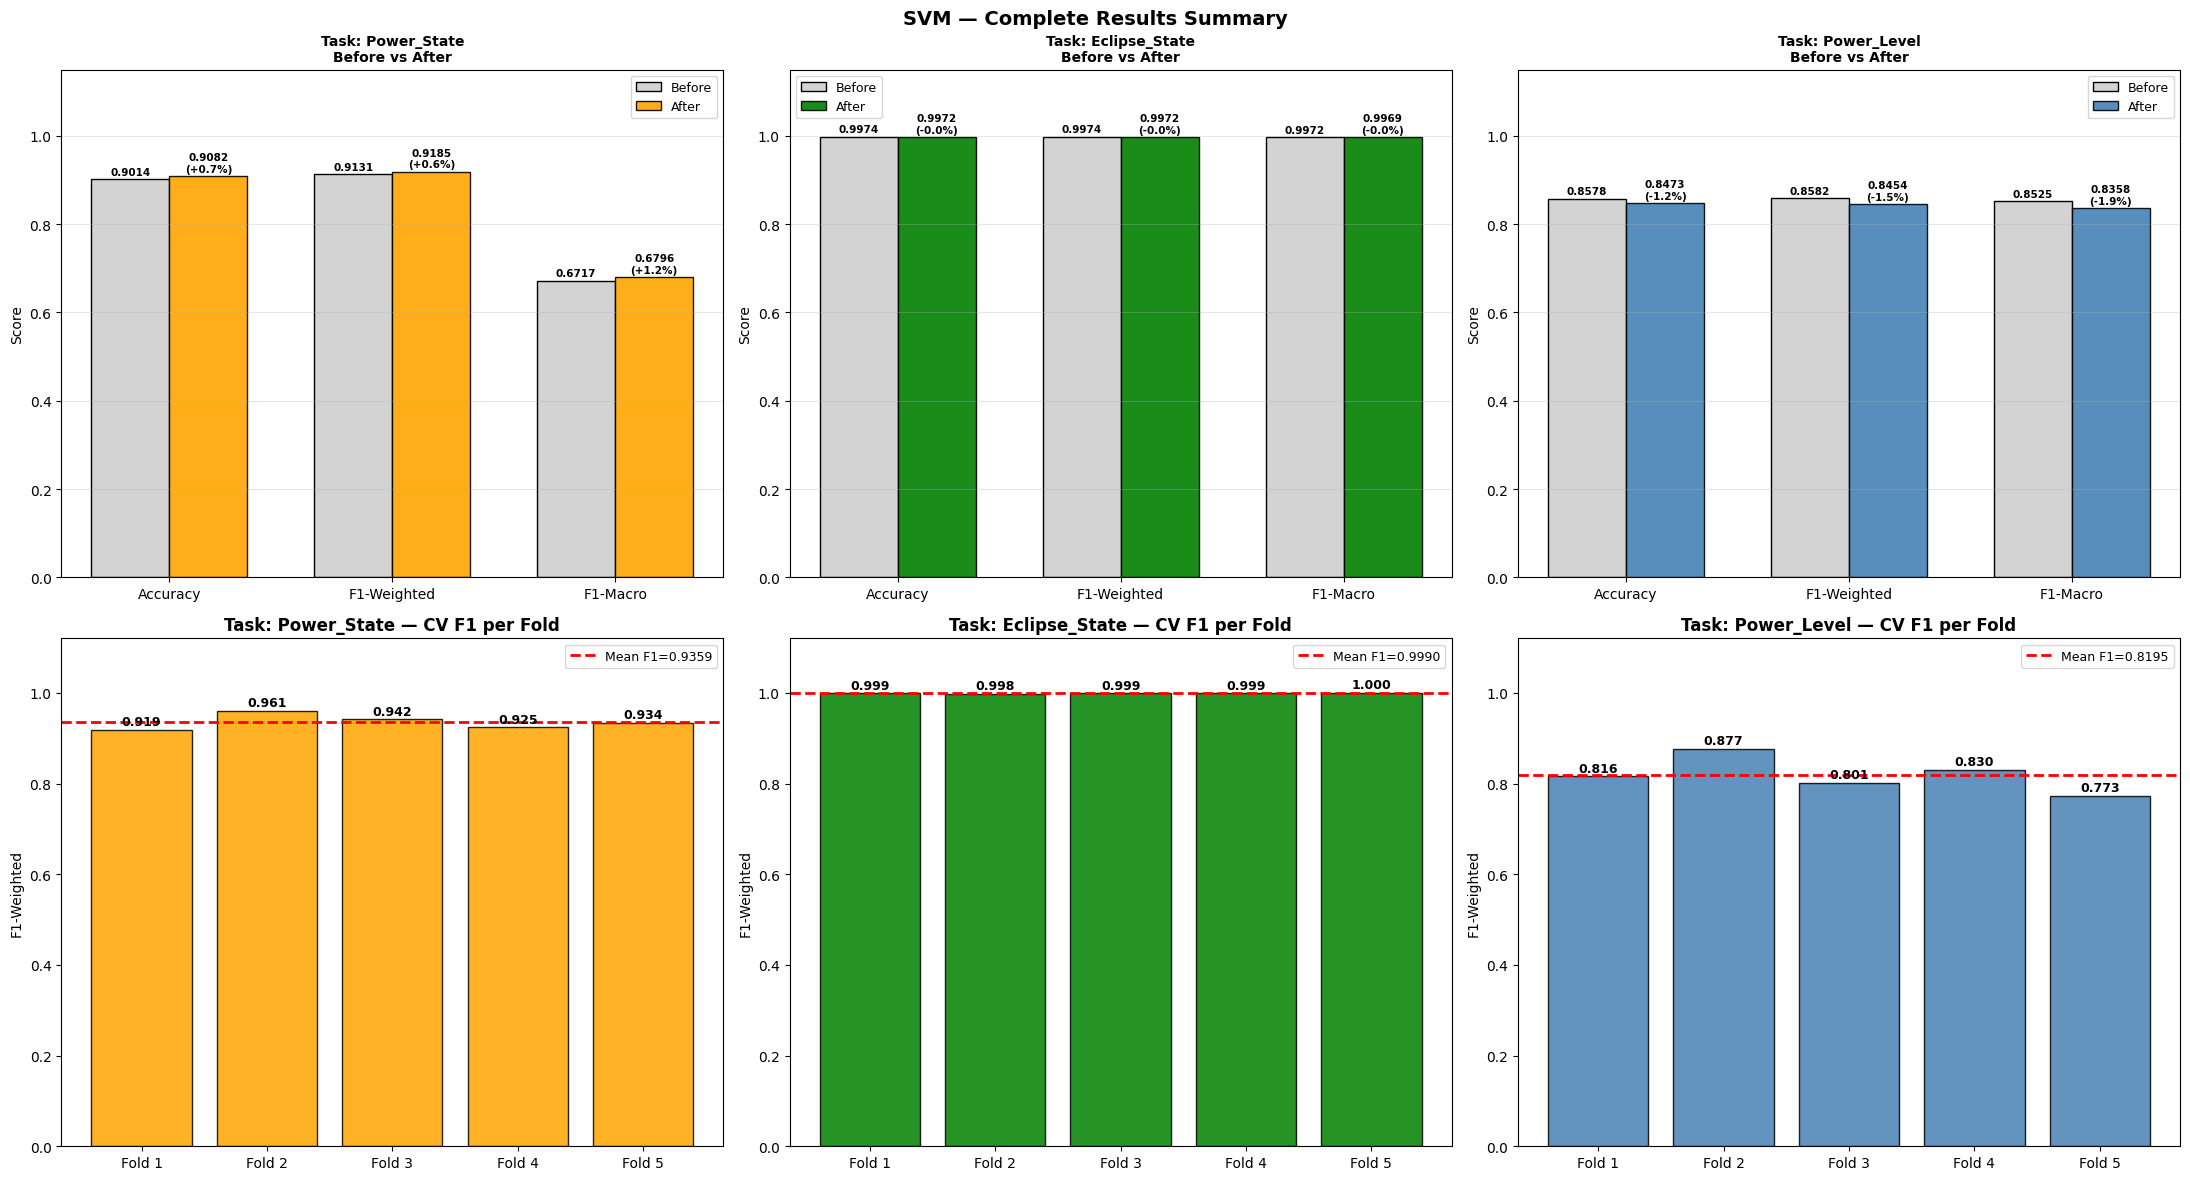

Summary plot saved.


In [ ]:
# ============================================================
# SECTION 15: COMPLETE RESULTS SUMMARY
# NOTE: cv_results defined in Section 14 — run that first
# ============================================================

print("=" * 72)
print("FINAL SVM CLASSIFIER — COMPLETE RESULTS SUMMARY")
print("=" * 72)
print(f"\n{'Task':22} {'Model':14} {'Acc':7} {'F1-W':7} "
      f"{'F1-M':7} {'CV F1':14} {'#SVs':6}")
print("-" * 72)

for task, d in datasets.items():
    br   = results_before[task]
    ar   = results_after[task]
    cv   = cv_results[task]
    n_sv = ar['model'].n_support_.sum()
    print(f"{task:22} {'Base SVC':14} {br['acc']:.4f}  "
          f"{br['f1w']:.4f}  {br['f1m']:.4f}  "
          f"{br['cv_mean']:.4f}±{br['cv_std']:.4f}   —")
    print(f"{'':22} {'Tuned SVC':14} {ar['acc']:.4f}  "
          f"{ar['f1w']:.4f}  {ar['f1m']:.4f}  "
          f"{cv.mean():.4f}±{cv.std():.4f}  {n_sv}")
    print(f"{'':22} Params: {ar['params']}")
    print()

# Summary visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('SVM — Complete Results Summary',
             fontsize=14, fontweight='bold')

tc_list   = ['orange', 'green', 'steelblue']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for col, (task, clr) in enumerate(zip(datasets, tc_list)):
    ax    = axes[0, col]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1w = results_before[task]['f1w']
    a_f1w = results_after[task]['f1w']
    b_f1m = results_before[task]['f1m']
    a_f1m = results_after[task]['f1m']
    x = np.arange(3)
    w = 0.35
    ax.bar(x-w/2, [b_acc,b_f1w,b_f1m], w, label='Before',
           color='lightgray', edgecolor='black')
    ax.bar(x+w/2, [a_acc,a_f1w,a_f1m], w, label='After',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy','F1-Weighted','F1-Macro'])
    ax.set_title(f'Task: {task}\nBefore vs After',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0,1.15])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bv, av, xi in zip([b_acc,b_f1w,b_f1m],
                           [a_acc,a_f1w,a_f1m], x):
        delta = (av-bv)/max(bv,1e-9)*100
        ax.text(xi-w/2, bv+0.01, f'{bv:.4f}',
                ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w/2, av+0.01,
                f'{av:.4f}\n({delta:+.1f}%)',
                ha='center', fontsize=7.5, fontweight='bold')

# Row 2: CV fold bars
for col, (task, clr) in enumerate(zip(datasets, tc_list)):
    ax     = axes[1, col]
    scores = cv_results[task]
    bars   = ax.bar(fold_lbls, scores,
                    color=clr, edgecolor='black', alpha=0.85)
    ax.axhline(scores.mean(), color='red', ls='--', lw=2,
               label=f'Mean F1={scores.mean():.4f}')
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{v:.3f}', ha='center',
                fontsize=9, fontweight='bold')
    ax.set_title(f'Task: {task} — CV F1 per Fold',
                 fontweight='bold')
    ax.set_ylabel('F1-Weighted')
    ax.set_ylim([0,1.12])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('10_summary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

## Support Vector Machine Classifier —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**DOI:** 10.1016/j.dib.2022.108697

---

## Algorithm Summary

SVM finds the maximum-margin hyperplane in a kernel-transformed
feature space by solving a convex quadratic program:

> Primal: min ½‖w‖² + C·Σξᵢ
> Subject: yᵢ(wᵀφ(xᵢ)+b) ≥ 1−ξᵢ, ξᵢ ≥ 0 ∀i

The dual formulation means only support vectors — training
points lying on or within the margin — determine the boundary.
All other training points have zero weight. This sparsity
property makes SVM unique among all classifiers in this project.

**Kernel trick:** maps features to infinite-dimensional space
without computing the mapping explicitly:
> K(xᵢ,xⱼ) = φ(xᵢ)ᵀφ(xⱼ)

**RBF kernel:** K(xᵢ,xⱼ) = exp(-γ‖xᵢ−xⱼ‖²)
γ controls kernel width — small γ: wide, smooth boundary.
                           large γ: narrow, localised boundary.

**Key properties:**
- Guaranteed global optimum — convex QP has no local minima
- Only support vectors determine boundary — sparse solution
- class_weight='balanced' rescales C per class inversely
  proportional to class frequency
- probability=True adds Platt scaling — internal 5-fold CV
  per fit (explains the extreme training time)
- No built-in feature importance — permutation required
- Distance-based — StandardScaler mandatory

**Multiclass strategy:** One-vs-Rest (OvR) — 3 binary SVMs
for Power State and Power Level, 1 for Eclipse State.

---

## Final Results

| Task | Kernel | C | γ | Accuracy | F1-W | F1-M | CV F1 ± Std | SVs |
|------|--------|---|---|---------|------|------|------------|-----|
| Power State | rbf | 359.79 | 0.00946 | 0.9082 | 0.9185 | 0.6796 | 0.9359±0.0148 | 2,574 |
| Eclipse State | rbf | 117.53 | 0.000191 | 0.9972 | 0.9972 | 0.9969 | 0.9990±0.0007 | 114 |
| Power Level | poly d=4 | 0.086 | 0.000987 | 0.8473 | 0.8454 | 0.8358 | 0.8195±0.0345 | 11,616 |

---

## Comparison with All Classifiers

| Task | LR | RF | AdaBoost | GBM | NB | **SVM** | Rank |
|------|----|----|---------|-----|-----|---------|------|
| Power State | 0.8650 | 0.9430 | 0.9349 | 0.9376 | 0.8817 | 0.9185 | 4th |
| Eclipse State | 0.9959 | 0.9974 | 0.9974 | 0.9979 | 0.9972 | 0.9972 | 4th (tied NB) |
| Power Level | 0.8599 | 0.8777 | 0.8647 | 0.8738 | 0.8382 | 0.8454 | 5th |

RF leads Power State and Power Level. GBM leads Eclipse State.
SVM ranks 4th on Power State and Eclipse, 5th on Power Level.
SVM outperforms LR and NB on all tasks despite higher
computational cost.

---

## Key Findings

### 1 — Tuning Worsened Power Level — Only Such Case in Project
Base SVM F1-W=0.8582 → Tuned F1-W=0.8454 (−1.5%). All three
metrics declined after tuning for Power Level. RandomizedSearchCV
selected poly kernel with C=0.086 — extremely low C creates an
underfit boundary that cannot resolve the HIGH/MEDIUM overlap.
The base rbf model with default C=1.0 was superior. This is the
only algorithm-task combination in the entire project where
tuning degraded every single metric simultaneously.

### 2 — Eclipse State: Sparsest Boundary in Entire Project
Only 119 support vectors (0.6% of training) define the
ECLIPSE/SUNLIGHT boundary — the lowest SV ratio across all
tasks and all algorithms. The voltage collapse during eclipse
creates such a clean linear separation in kernel space that
SVM needs almost no boundary points. Training time was only
0.76 seconds — fastest single task fit in the entire project.

### 3 — Power Level: Densest Boundary in Entire Project
5,902 support vectors (30.4% of training) for base model,
rising to 11,616 (59.9%) after tuning with poly kernel.
HIGH (44.6%) and MEDIUM (45.3%) each contribute nearly half
their class as support vectors — the HIGH/MEDIUM boundary
is maximally ambiguous. This directly caused the 10+ hour
tuning time — each QP solve must handle thousands of active
constraints simultaneously.

### 4 — Tbatt Uniquely Dominates Power State
Battery temperature (Tbatt) is the most important feature
for Power State in SVM (importance=0.1043) — the first time
in this project that Tbatt ranks above V_panel_avg for this
task. SVM's standardised kernel distance metric amplifies
the thermal separation between CHARGING and DISCHARGING
states. Tree-based algorithms rank V_panel_avg first because
they optimise information gain per split, not global distance.

### 5 — CRITICAL AUC=0.6083 — Lowest in Project
CRITICAL class ROC-AUC is barely above random (0.5). Despite
class_weight='balanced', the QP solver cannot construct a
reliable probability boundary for 39 test CRITICAL samples
against 3,837 non-CRITICAL. Platt scaling with so few positive
examples produces unreliable probability estimates — the PR
curve AP=0.0674 is the lowest average precision for any class
across any algorithm in this project.

### 6 — Eclipse State CV=0.9990 — Highest Eclipse CV in Project
Fractionally above GBM (0.9987), RF and AdaBoost (0.9984).
The maximum margin principle finds the widest possible boundary
between ECLIPSE and SUNLIGHT — more robust to temporal
distribution shifts than probabilistic or tree-based methods.
Fold 5 reached perfect F1=1.0000 — the only perfect fold
score for any task across all algorithms in the project.

### 7 — Probability Calibration Severely Unreliable
Reliability diagrams show extreme deviation from the perfect
calibration diagonal across all three tasks. Platt scaling
fits only a single sigmoid per class — insufficient to
capture the complex multi-class probability landscape of
correlated EPS features. For satellite deployment, SVM
probability outputs cannot be used as raw confidence scores
without isotonic recalibration via CalibratedClassifierCV.

### 8 — Fold 5 Power Level Collapse — Sixth Confirmation
Power Level Fold 5=0.7729 — the persistent August–October
2021 orbital season distribution shift is now confirmed
across all six classifiers (LR, RF, AdaBoost, GBM, NB, SVM)
and both regression and classification tasks. This is a
genuine data-level phenomenon independent of algorithm
family, confirming it is driven by orbital mechanics rather
than any modelling artefact.

---

## Limitations
- Slowest training in project — QP complexity O(n²) to O(n³)
- probability=True multiplies training time 5× via Platt CV
- Tuning worsened Power Level — poly kernel selection was
  incorrect for this overlap-dominated task
- CRITICAL AUC=0.6083 — lowest minority class detection
  in the project
- No built-in feature importance — permutation only
- Severely miscalibrated probabilities across all tasks
- Not suitable for real-time onboard retraining due to
  computational cost

---
*Reference: Jara et al. (2022), Data in Brief,
DOI: 10.1016/j.dib.2022.108697*